In [ ]:
#data collection(kaggle)

In [4]:
import os
from pathlib import Path
import pandas as pd
import kagglehub

def check_kaggle_json_windows():
    kaggle_json = Path.home() / ".kaggle" / "kaggle.json"
    if not kaggle_json.exists():
        raise FileNotFoundError(
            f" kaggle.json not found at: {kaggle_json}\n"
            "Fix (Windows): Put your kaggle.json inside:\n"
            "  C:\\Users\\<user>\\.kaggle\\kaggle.json\n"
        )
    print(f" kaggle.json found: {kaggle_json}")

check_kaggle_json_windows()

DATASETS = {
    # STRESS DATASETS
    "stress_prediction": "kreeshrajani/human-stress-prediction",
    "heartrate_stresslevel": "vinayakshanawad/heart-rate-prediction-to-monitor-stress-level",
    "screentime_stress": "adharshinikumar/screentime-vs-mentalwellness-survey-2025",
    "mentalhealth_workplace": "khushikyad001/mental-health-and-burnout-in-the-workplace",
    "student_academic_stress": "poushal02/student-academic-stress-real-world-dataset",
    "student_mental": "salahuddinahmedshuvo/student-mental-stress-and-coping-mechanisms",
    "university_student": "yuanchunhong/university-student-mental-health-indicators",
    "osmi_mental_health": "osmihelp/osmi-mental-health-in-tech-survey-2017",

    # WEARABLE DATASETS
    "wearable_device": "protobioengineering/wearable-device-dataset-during-stress-and-exercise",
    "wesad_wearable": "orvile/wesad-wearable-stress-affect-detection-dataset",  
    "health_lifestyle": "sahilislam007/health-and-lifestyle-dataset",

    # ENVIRONMENTAL DATASETS
    "environmental_sensor": "garystafford/environmental-sensor-data-132k",
    "weather_air_quality": "aatifahmad123/weather-and-air-quality-of-indian-cities",
    "pollution_india": "venky73/airquality",
    "noise_india": "rohanrao/noise-monitoring-data-in-india"
}

download_paths = {}
for name, slug in DATASETS.items():
    path = kagglehub.dataset_download(slug)
    download_paths[name] = str(path)
    print(f" {name} downloaded to: {path}")

print("\n Download complete:", len(download_paths), "datasets")


 kaggle.json found: C:\Users\user\.kaggle\kaggle.json
 stress_prediction downloaded to: C:\Users\user\.cache\kagglehub\datasets\kreeshrajani\human-stress-prediction\versions\1
 heartrate_stresslevel downloaded to: C:\Users\user\.cache\kagglehub\datasets\vinayakshanawad\heart-rate-prediction-to-monitor-stress-level\versions\1
 screentime_stress downloaded to: C:\Users\user\.cache\kagglehub\datasets\adharshinikumar\screentime-vs-mentalwellness-survey-2025\versions\1
 mentalhealth_workplace downloaded to: C:\Users\user\.cache\kagglehub\datasets\khushikyad001\mental-health-and-burnout-in-the-workplace\versions\1
 student_academic_stress downloaded to: C:\Users\user\.cache\kagglehub\datasets\poushal02\student-academic-stress-real-world-dataset\versions\2
 student_mental downloaded to: C:\Users\user\.cache\kagglehub\datasets\salahuddinahmedshuvo\student-mental-stress-and-coping-mechanisms\versions\1
 university_student downloaded to: C:\Users\user\.cache\kagglehub\datasets\yuanchunhong\unive

In [3]:
#load main files (largest tabular file per dataset folder)

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

raw_data = {}

TAB_EXTS = {".csv", ".tsv", ".xlsx", ".xls", ".json"}

# SETTINGS FOR HUGE FILES

MAX_ROWS_PER_BIG_FILE = 300_000
BIG_DATASETS = {"wearable_device", "wesad_wearable"}  

# Robust reader

def read_any_table(path, dataset_name=None):
    p = Path(path)
    ext = p.suffix.lower()
    nrows = MAX_ROWS_PER_BIG_FILE if dataset_name in BIG_DATASETS else None

    if ext in [".csv", ".tsv"]:
        for sep in [",", "\t", ";", "|"]:
            try:
                return pd.read_csv(
                    p, sep=sep, low_memory=False, encoding_errors="ignore",
                    nrows=nrows
                )
            except Exception:
                continue
        return pd.read_csv(p, low_memory=False, encoding_errors="ignore", nrows=nrows)

    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(p)

    if ext == ".json":
        try:
            return pd.read_json(p, lines=True)
        except Exception:
            return pd.read_json(p)

    raise ValueError(f"Unsupported extension: {ext} | file={p.name}")

# Fast-ish row counter for CSV/TSV (chunk-based)

def count_rows_csv(path, chunksize=200_000):
    total = 0
    for sep in [",", "\t", ";", "|"]:
        try:
            total = 0
            for chunk in pd.read_csv(path, sep=sep, chunksize=chunksize, low_memory=False, encoding_errors="ignore"):
                total += len(chunk)
            if total > 0:
                return total
        except Exception:
            continue
# fallback
    total = 0
    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False, encoding_errors="ignore"):
        total += len(chunk)
    return total

def count_rows_any(path):
    p = Path(path)
    ext = p.suffix.lower()
    try:
        if ext in [".csv", ".tsv"]:
            return count_rows_csv(p)
        if ext in [".xlsx", ".xls"]:
            return len(pd.read_excel(p))
        if ext == ".json":
            try:
                return len(pd.read_json(p, lines=True))
            except Exception:
                return len(pd.read_json(p))
    except Exception:
        return None
    return None


# Find largest tabular file inside each dataset folder

main_file_map = {}  # dataset_name -> best_file_path

for ds_name, folder in download_paths.items():
    folder = Path(folder)
    files = [fp for fp in folder.rglob("*") if fp.is_file() and fp.suffix.lower() in TAB_EXTS]

    # WESAD: we still load one tabular file (optional), but PKLs are main source for modeling
    if len(files) == 0:
        print(f" No tabular files found for {ds_name}")
        continue

    # choose by row count (best effort)
    best_fp, best_rows = None, -1
    for fp in files:
        r = count_rows_any(fp)
        if r is None:
            continue
        if r > best_rows:
            best_rows = r
            best_fp = fp

    # fallback if no row counts worked: pick largest by bytes
    if best_fp is None:
        best_fp = max(files, key=lambda x: x.stat().st_size)
        best_rows = None

    main_file_map[ds_name] = str(best_fp)
    print(f" Main file for {ds_name}: {best_fp.name} | rows={best_rows}")

#  Load each dataset main file

for ds_name, fp in main_file_map.items():
    try:
        df = read_any_table(fp, dataset_name=ds_name)
        raw_data[ds_name] = df
        print(f" Loaded {ds_name}: shape={df.shape}")
    except Exception as e:
        print(f" Failed loading {ds_name}: {e}")

#  WESAD PKL FILES → defines WESAD_PKL_PATHS

wesad_path = Path(download_paths["wesad_wearable"])
WESAD_PKL_PATHS = sorted(wesad_path.rglob("*.pkl"))

print(f"\n WESAD folder: {wesad_path}")
print(f" WESAD .pkl files found: {len(WESAD_PKL_PATHS)}")
print("Subjects:", [p.stem for p in WESAD_PKL_PATHS])

if len(WESAD_PKL_PATHS) == 0:
    raise FileNotFoundError(" No WESAD PKL files found. Check download_paths['wesad_wearable'].")

print("\n RAW LOADING COMPLETE: raw_data + WESAD_PKL_PATHS are ready.")


 Main file for stress_prediction: Stress.csv | rows=2838
 Main file for heartrate_stresslevel: frequency_domain_features_train.csv | rows=369289
 Main file for screentime_stress: ScreenTime vs MentalWellness.csv | rows=400
 Main file for mentalhealth_workplace: mental_health_workplace_survey.csv | rows=3000
 Main file for student_academic_stress: academic Stress level - maintainance 1.csv | rows=140
 Main file for student_mental: Student_Mental_Stress_and_Coping_Mechanisms.csv | rows=760
 Main file for university_student: data.csv | rows=1800
 Main file for osmi_mental_health: OSMI Mental Health in Tech Survey 2017.csv | rows=756
 Main file for wearable_device: BVP.csv | rows=307792
 Main file for wesad_wearable: BVP.csv | rows=532709
 Main file for health_lifestyle: synthetic_health_lifestyle_dataset.csv | rows=7500
 Main file for environmental_sensor: iot_telemetry_data.csv | rows=405184
 Main file for weather_air_quality: indian_weather_data.csv | rows=74
 Main file for pollution_in

In [5]:
#preprocessing

In [6]:
import numpy as np
import pandas as pd
import pickle

clean_data = {}

# A) Generic tabular cleaning - drop & fill

def standardize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
          .str.strip()
          .str.lower()
          .str.replace(r"[^\w]+", "_", regex=True)
          .str.strip("_")
    )
    return df

def drop_duplicate_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[:, ~df.columns.duplicated()].copy()

def drop_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop_duplicates()

def fix_object_numbers(df: pd.DataFrame, max_unique_ratio=0.6) -> pd.DataFrame:
    df = df.copy()
    obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
    n = len(df)
    for c in obj_cols:
        nun = df[c].nunique(dropna=True)
        if nun == 0:
            continue
        if (nun / max(n, 1)) > max_unique_ratio:
            continue
        converted = pd.to_numeric(df[c], errors="coerce")
        if converted.notna().sum() > 0 and converted.notna().sum() >= int(0.2 * n):
            df[c] = converted
    return df

def drop_constant_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    const = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
    return df.drop(columns=const, errors="ignore")

def fill_missing_simple(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for c in df.columns:
        if pd.api.types.is_numeric_dtype(df[c]):
            if df[c].isna().any():
                df[c] = df[c].fillna(df[c].median())
        else:
            if df[c].isna().any():
                mode = df[c].mode(dropna=True)
                df[c] = df[c].fillna(mode.iloc[0] if len(mode) > 0 else "unknown")
    return df

POSSIBLE_STRESS_LABELS = [
    "stress_target", "stress", "label", "target",
    "stress_level", "stresslevel", "stress_level_0_10",
    "rate_your_academic_stress_index", "financial_stress", "onlinestress"
]

def make_stress_target(df: pd.DataFrame):
    df = df.copy()
    lower_map = {c.lower(): c for c in df.columns}
    label_col = None
    for k in POSSIBLE_STRESS_LABELS:
        if k in lower_map:
            label_col = lower_map[k]
            break

    if label_col is None:
        return df, None, False

    if label_col.lower() == "stress_target":
        df["stress_target"] = pd.to_numeric(df[label_col], errors="coerce").fillna(0).astype(int)
        return df, label_col, True

    s = pd.to_numeric(df[label_col], errors="coerce")
    if s.notna().sum() == 0:
        return df, label_col, False

    if s.max() <= 10:
        df["stress_target"] = (s >= 6).astype(int)
        return df, label_col, True

    if s.max() <= 5:
        df["stress_target"] = (s >= 3).astype(int)
        return df, label_col, True

    med = s.median()
    df["stress_target"] = (s >= med).astype(int)
    return df, label_col, True


#  IMPORTANT: skip WESAD tabular CSV because PKLs are the real data
SKIP_TABULAR = {"wesad_wearable"}

summary = []
for name, df in raw_data.items():
    if name in SKIP_TABULAR:
        summary.append({
            "dataset": name,
            "rows_before": len(df),
            "rows_after": len(df),
            "cols_after": df.shape[1],
            "label_col_found": None,
            "stress_target_created": False,
            "note": "Skipped (WESAD uses PKL files)"
        })
        continue

    d0 = df.copy()
    before = len(d0)

    d0 = standardize_cols(d0)
    d0 = drop_duplicate_columns(d0)
    d0 = drop_duplicate_rows(d0)
    d0 = fix_object_numbers(d0)
    d0 = drop_constant_columns(d0)
    d0 = fill_missing_simple(d0)

    d0, label_col, created = make_stress_target(d0)
    clean_data[name] = d0

    summary.append({
        "dataset": name,
        "rows_before": before,
        "rows_after": len(d0),
        "cols_after": d0.shape[1],
        "label_col_found": label_col,
        "stress_target_created": bool(created),
        "note": ""
    })

summary_df = pd.DataFrame(summary).sort_values("rows_after", ascending=False)
print("Tabular preprocessing done. Output stored in clean_data")
display(summary_df)



# B) WESAD: Window feature extraction (SUPERVISED BASE)  FINAL

MIN_LABEL_FRAC = 0.60   # majority threshold
BASELINE_LABEL = 1
STRESS_LABEL   = 2

def window_features_1d(x: np.ndarray):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    if len(x) == 0 or np.isnan(x).all():
        return {"mean": 0.0, "std": 0.0}
    return {"mean": float(np.nanmean(x)), "std": float(np.nanstd(x))}

def align_labels_to_length(y_full: np.ndarray, n: int) -> np.ndarray:
    y_full = np.asarray(y_full).reshape(-1)
    if len(y_full) == n:
        return y_full.astype(int)
    idx = np.linspace(0, len(y_full) - 1, n).astype(int)
    return y_full[idx].astype(int)

def slice_by_ratio(arr, start_ref, end_ref, n_ref):
    if arr is None:
        return None
    arr = np.asarray(arr)
    n_sig = arr.shape[0]
    if n_sig <= 1 or n_ref <= 1:
        return None
    s = int(round(start_ref * (n_sig / n_ref)))
    e = int(round(end_ref   * (n_sig / n_ref)))
    s = max(0, min(s, n_sig - 1))
    e = max(s + 1, min(e, n_sig))
    return arr[s:e]

def build_wesad_windows_v4(
    pkl_paths,
    window_sec=60,
    step_sec=30,
    fs_ref=64,                 # BVP wrist ~64Hz
    max_windows_per_subject=1500,
    balance_per_subject=True,
    seed=42
):
    rows = []
    rng = np.random.RandomState(seed)

    w = int(window_sec * fs_ref)
    s = int(step_sec * fs_ref)

    for pkl_path in pkl_paths:
        subj = pkl_path.stem.upper()

        try:
            with open(pkl_path, "rb") as f:
                data = pickle.load(f, encoding="latin1")
        except Exception as e:
            print(f" Skip {pkl_path.name}: cannot load ({e})")
            continue

        if not (isinstance(data, dict) and "signal" in data and "label" in data):
            print(f" Skip {pkl_path.name}: missing signal/label")
            continue

        wrist = data["signal"].get("wrist", {})
        if not isinstance(wrist, dict):
            print(f" Skip {pkl_path.name}: wrist not dict")
            continue

        bvp  = wrist.get("BVP", None)
        acc  = wrist.get("ACC", None)
        eda  = wrist.get("EDA", None)
        temp = wrist.get("TEMP", None)

        if bvp is None:
            print(f" Skip {pkl_path.name}: missing BVP")
            continue

        ref = np.asarray(bvp).reshape(-1)
        n_ref = len(ref)
        if n_ref < w:
            print(f" Skip {pkl_path.name}: too short for windows")
            continue

        y = align_labels_to_length(np.asarray(data["label"]), n_ref)

        candidates = []
        win_id = 0

        for start in range(0, n_ref - w + 1, s):
            end = start + w
            lab_win = y[start:end]

            vals, cnts = np.unique(lab_win, return_counts=True)
            maj_label = int(vals[np.argmax(cnts)])
            maj_frac = float(cnts.max() / len(lab_win))

            #  keep only baseline/stress with strong majority
            if maj_frac < MIN_LABEL_FRAC:
                continue
            if maj_label not in (BASELINE_LABEL, STRESS_LABEL):
                continue

            stress_target = 1 if maj_label == STRESS_LABEL else 0
            candidates.append((win_id, start, end, stress_target))
            win_id += 1

        if not candidates:
            continue

        #  Balanced per subject (sampling indices)
        if balance_per_subject:
            zero_idx = [i for i, c in enumerate(candidates) if c[3] == 0]
            one_idx  = [i for i, c in enumerate(candidates) if c[3] == 1]

            if len(zero_idx) > 0 and len(one_idx) > 0:
                k = min(len(zero_idx), len(one_idx), max_windows_per_subject // 2)
                pick_zero = rng.choice(zero_idx, size=k, replace=False)
                pick_one  = rng.choice(one_idx,  size=k, replace=False)
                pick_idx = np.concatenate([pick_zero, pick_one])
                rng.shuffle(pick_idx)
                candidates = [candidates[i] for i in pick_idx]

        candidates = candidates[:max_windows_per_subject]

        # build rows
        for win_id, start, end, stress_target in candidates:
            row = {"subject_id": subj, "window_id": int(win_id), "stress_target": int(stress_target)}

            # BVP features
            f = window_features_1d(ref[start:end])
            row.update({f"bvp_{k}": v for k, v in f.items()})

            # EDA/TEMP/ACC mapped by ratio (if present)
            if eda is not None:
                e_win = slice_by_ratio(np.asarray(eda).reshape(-1), start, end, n_ref)
                if e_win is not None:
                    f = window_features_1d(e_win)
                    row.update({f"eda_{k}": v for k, v in f.items()})

            if temp is not None:
                t_win = slice_by_ratio(np.asarray(temp).reshape(-1), start, end, n_ref)
                if t_win is not None:
                    f = window_features_1d(t_win)
                    row.update({f"temp_{k}": v for k, v in f.items()})

            if acc is not None:
                a_win = slice_by_ratio(np.asarray(acc), start, end, n_ref)
                if a_win is not None and a_win.ndim == 2 and a_win.shape[1] == 3:
                    for i in range(3):
                        f = window_features_1d(a_win[:, i])
                        row.update({f"acc_{i}_{k}": v for k, v in f.items()})

            rows.append(row)

    return pd.DataFrame(rows)

wesad_windows_df = build_wesad_windows_v4(
    WESAD_PKL_PATHS,
    window_sec=60,
    step_sec=30,
    fs_ref=64,
    max_windows_per_subject=1500,
    balance_per_subject=True
)

clean_data["wesad_windows"] = wesad_windows_df

print("\n WESAD window dataset ready (v4)")
print("Shape:", wesad_windows_df.shape)
print("\nStress distribution:")
print(wesad_windows_df["stress_target"].value_counts())
print("\nSubjects:", wesad_windows_df["subject_id"].nunique())

# hard check
if wesad_windows_df.empty or wesad_windows_df["stress_target"].nunique() < 2:
    raise ValueError(
        "WESAD target has only ONE class after filtering.\n"
        "Try: MIN_LABEL_FRAC=0.55 OR window_sec=30 step_sec=15."
    )

Tabular preprocessing done. Output stored in clean_data


,dataset,rows_before,rows_after,cols_after,label_col_found,stress_target_created,note
11,environmental_sensor,405184,405171,9,None,False,
1,heartrate_stresslevel,369289,369289,12,None,False,
9,wesad_wearable,300000,300000,1,None,False,Skipped (WESAD uses PKL files)
8,wearable_device,300000,16557,1,None,False,
10,health_lifestyle,7500,7500,14,stress_level,True,
14,noise_india,5005,5005,7,None,False,
3,mentalhealth_workplace,3000,3000,26,stresslevel,True,
0,stress_prediction,2838,2838,8,label,True,
6,university_student,1800,1800,17,onlinestress,True,
13,pollution_india,824,824,7,None,False,



 WESAD window dataset ready (v4)
Shape: (654, 15)

Stress distribution:
stress_target
0    327
1    327
Name: count, dtype: int64

Subjects: 15


In [7]:
#  TIMESTAMP PARSING 
#   Applies ONLY to ENV datasets in clean_data
#    Handles:
#      - string datetime columns (created_at, datetime, date, time, etc.)
#      - epoch columns (ts, timestamp) in s/ms/us/ns (auto-detect)
#    Creates new columns:
#      - <col>_dt for parsed datetime (keeps original intact)
import pandas as pd
import numpy as np

ENV_DATASETS = ["environmental_sensor", "weather_air_quality", "noise_india", "pollution_india"]

# string-like datetime hints
STRING_TIME_HINTS = [
    "datetime", "created", "recorded", "date", "time", "timestamp", "updated", "logged"
]

# epoch-like hints
EPOCH_HINTS = ["ts", "timestamp", "epoch", "unix"]

def _safe_to_datetime_string(s: pd.Series) -> pd.Series:
    """Parse object/string-like datetime safely."""
    return pd.to_datetime(s, errors="coerce", infer_datetime_format=True)

def _safe_to_datetime_epoch(s: pd.Series) -> pd.Series:
    """
    Parse numeric-like epoch safely with auto unit detection.
    Supports seconds/ms/us/ns using magnitude.
    """
    s_num = pd.to_numeric(s, errors="coerce")
    if s_num.notna().mean() < 0.30:
        return pd.Series(pd.NaT, index=s.index)

    med = float(s_num.dropna().median()) if s_num.notna().any() else 0.0

    # Rough magnitude thresholds:
    # seconds ~ 1e9, ms ~ 1e12, us ~ 1e15, ns ~ 1e18
    if med > 1e17:
        unit = "ns"
    elif med > 1e14:
        unit = "us"
    elif med > 1e11:
        unit = "ms"
    else:
        unit = "s"

    return pd.to_datetime(s_num, errors="coerce", unit=unit)

def add_datetime_columns(df: pd.DataFrame, min_success_ratio=0.30) -> pd.DataFrame:
    df = df.copy()

    for c in df.columns:
        cl = str(c).lower()

        # don't re-parse already parsed columns
        if cl.endswith("_dt"):
            continue

        # skip if already datetime dtype
        if pd.api.types.is_datetime64_any_dtype(df[c]):
            continue

        # 1) EPOCH parsing
        if any(h == cl or h in cl for h in EPOCH_HINTS):
            parsed = _safe_to_datetime_epoch(df[c])
            if parsed.notna().mean() >= min_success_ratio:
                df[f"{c}_dt"] = parsed
            continue


        # 2) STRING datetime parsing
        if df[c].dtype == "object" and any(h in cl for h in STRING_TIME_HINTS):
            parsed = _safe_to_datetime_string(df[c])
            if parsed.notna().mean() >= min_success_ratio:
                df[f"{c}_dt"] = parsed

    return df


# Apply to ENV datasets only
for name in ENV_DATASETS:
    if name in clean_data and isinstance(clean_data[name], pd.DataFrame) and not clean_data[name].empty:
        before_cols = set(clean_data[name].columns)
        clean_data[name] = add_datetime_columns(clean_data[name], min_success_ratio=0.30)
        added = [c for c in clean_data[name].columns if c not in before_cols]

        if added:
            print(f" {name}: added datetime columns -> {added}")
        else:
            print(f" {name}: no datetime columns detected/parsed.")

print("\n Timestamp parsing applied to ENV datasets (safe mode, new *_dt columns).")


 environmental_sensor: added datetime columns -> ['ts_dt']
 weather_air_quality: no datetime columns detected/parsed.
 noise_india: no datetime columns detected/parsed.
 pollution_india: no datetime columns detected/parsed.

 Timestamp parsing applied to ENV datasets (safe mode, new *_dt columns).


In [8]:
# verification: show datetime + possible time columns in ENV datasets
ENV_DATASETS = ["environmental_sensor", "weather_air_quality", "noise_india", "pollution_india"]

for name in ENV_DATASETS:
    if name not in clean_data:
        continue
    df = clean_data[name]
    dt_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    time_like = [c for c in df.columns if any(k in c.lower() for k in ["ts", "time", "date", "timestamp", "epoch"])]
    print(f"\n{name}: shape={df.shape}")
    print("datetime cols:", dt_cols)
    print("time-like cols:", time_like[:20])



environmental_sensor: shape=(405171, 10)
datetime cols: ['ts_dt']
time-like cols: ['ts', 'ts_dt']

weather_air_quality: shape=(72, 24)
datetime cols: []
time-like cols: []

noise_india: shape=(5005, 7)
datetime cols: []
time-like cols: []

pollution_india: shape=(824, 7)
datetime cols: []
time-like cols: ['pollutants']


In [9]:
#EDA

In [10]:
#basic eda


--- BASIC EDA (DOMAIN AVERAGES) ---


,dataset_idx,rows,cols,numeric_cols,datetime_cols,missing_pct_avg,has_target
domain,,,,,,,
environment,1.5,102768.00,12.0,8.25,0.25,0.0,0.0
other,0.5,185022.50,48.5,18.00,0.00,0.0,0.0
stress,3.0,2348.29,16.0,11.29,0.00,0.0,1.0
wearable,0.0,654.00,15.0,14.00,0.00,0.0,1.0



--- BASIC EDA (PER DATASET SNAPSHOT) ---


,domain,dataset_name,dataset_idx,rows,cols,numeric_cols,datetime_cols,missing_pct_avg,has_target
0,environment,environmental_sensor,0,405171,10,6,1,0.0,False
1,environment,noise_india,3,5005,7,6,0,0.0,False
2,environment,pollution_india,2,824,7,3,0,0.0,False
3,environment,weather_air_quality,1,72,24,18,0,0.0,False
4,other,heartrate_stresslevel,0,369289,12,11,0,0.0,False
5,other,osmi_mental_health,1,756,85,25,0,0.0,False
6,stress,health_lifestyle,6,7500,14,8,0,0.0,True
7,stress,mentalhealth_workplace,2,3000,26,18,0,0.0,True
8,stress,stress_prediction,0,2838,8,4,0,0.0,True
9,stress,university_student,5,1800,17,17,0,0.0,True


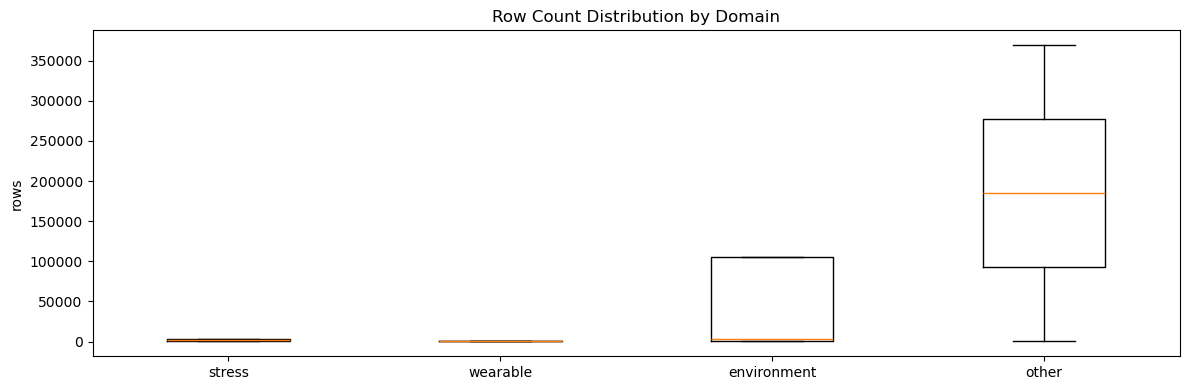

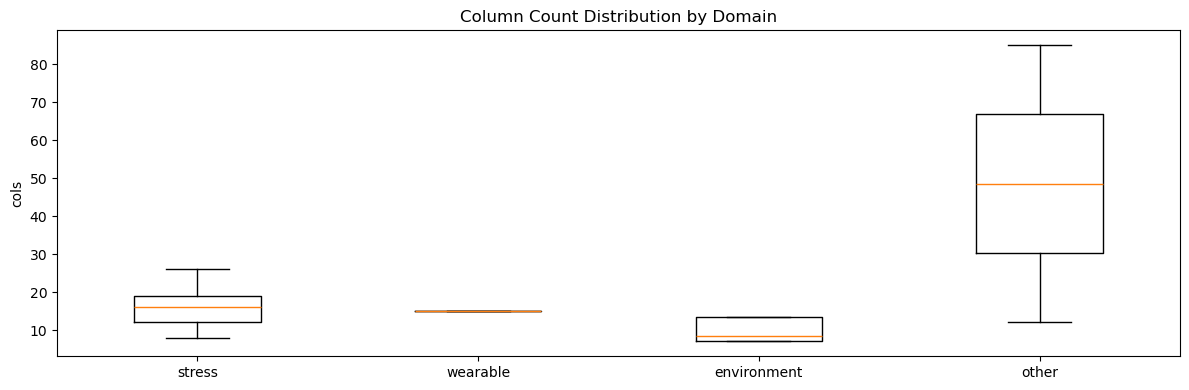

In [8]:
# =========================================================
# EDA PART 1: BASIC / SANITY (UPDATED FOR WESAD WINDOWS )
#    Uses wesad_windows as wearable (real features + target)
#    Excludes raw 1-col CSV streams (wesad_wearable, wearable_device)
#    Correct datetime detection (includes *_dt)
#    Correct has_target logic
#    Boxplot uses tick_labels (new matplotlib)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 0) DOMAIN BUCKETS (FIXED)

#  DO NOT include raw CSV streams as wearable
#   - "wesad_wearable" is the Kaggle folder CSV dump (BVP.csv etc) -> not for modeling
#   - "wearable_device" is also raw BVP.csv -> not for modeling
#  The real wearable modeling table is: clean_data["wesad_windows"]

DOMAIN_RULES = {
    "stress": {
        "stress_prediction", "health_lifestyle", "mentalhealth_workplace",
        "screentime_stress", "student_academic_stress", "student_mental",
        "university_student"
    },
    "wearable": {"wesad_windows"},  #  the correct wearable dataset
    "environment": {"environmental_sensor", "weather_air_quality", "pollution_india", "noise_india"},
    "other": {"osmi_mental_health", "heartrate_stresslevel"}
}

processed_data = {k: [] for k in DOMAIN_RULES.keys()}

# place datasets into buckets
for name, df in clean_data.items():
    placed = False
    for dom, nameset in DOMAIN_RULES.items():
        if name in nameset:
            processed_data[dom].append(df)
            placed = True
            break
    if not placed:
        # keep anything else in "other" (but skip raw wearable CSV dumps if present)
        if name not in {"wesad_wearable", "wearable_device"}:
            processed_data["other"].append(df)


# 1) HELPERS

TARGET_COL = "stress_target"

NON_FEATURE_COLS = {
    "id", "user_id", "subject_id", "window_id", "uuid", "index"
}

def safe_sample(df, n=3000, seed=42):
    if df.shape[0] > n:
        return df.sample(n, random_state=seed)
    return df

def count_datetime_cols(df):
    # counts real datetime dtype + any parsed *_dt columns
    dt_dtype = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).shape[1]
    dt_named = sum([str(c).lower().endswith("_dt") for c in df.columns])
    return int(max(dt_dtype, dt_named))  # safe

def has_target(df):
    return (TARGET_COL in df.columns)


# 2) BASIC SUMMARY TABLE

rows = []
for domain, dfs in processed_data.items():
    for i, df in enumerate(dfs):
        rows.append({
            "domain": domain,
            "dataset_name": [k for k,v in clean_data.items() if v is df][0] if df is not None else f"{domain}_{i}",
            "dataset_idx": i,
            "rows": df.shape[0],
            "cols": df.shape[1],
            "numeric_cols": df.select_dtypes(include=[np.number]).shape[1],
            "datetime_cols": count_datetime_cols(df),
            "missing_pct_avg": float(df.isna().mean().mean() * 100),
            "has_target": has_target(df)
        })

eda_basic = pd.DataFrame(rows)

print("\n--- BASIC EDA (DOMAIN AVERAGES) ---")
display(eda_basic.groupby("domain").mean(numeric_only=True).round(2))

print("\n--- BASIC EDA (PER DATASET SNAPSHOT) ---")
display(eda_basic.sort_values(["domain", "rows"], ascending=[True, False]).reset_index(drop=True))


# 3) SIZE DISTRIBUTION (BOXPLOTS)

def boxplot_by_domain(summary_df, col, title):
    doms = summary_df["domain"].unique().tolist()
    data = [summary_df.loc[summary_df["domain"] == d, col].values for d in doms]

    plt.figure(figsize=(12, 4))
    plt.boxplot(data, tick_labels=doms, showfliers=False)
    plt.title(title)
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

boxplot_by_domain(eda_basic, "rows", "Row Count Distribution by Domain")
boxplot_by_domain(eda_basic, "cols", "Column Count Distribution by Domain")

In [12]:
# main eda


--- TOP VARIANCE FEATURES (stress) ---


age              219.961877
weight_kg        214.204487
height_cm        100.138549
bmi               41.406012
stress_level       8.167468
sleep_hours        2.183546
stress_target      0.249858
dtype: float64


--- LOW VARIANCE FEATURES (< 0.01) (stress) ---
None 

--- TOP VARIANCE FEATURES (wearable) ---


bvp_std          1998.444128
acc_0_mean       1803.055610
acc_1_mean        829.444291
acc_2_mean        678.464475
acc_2_std          84.431636
acc_1_std          58.303674
acc_0_std          34.894980
eda_mean            9.273614
temp_mean           1.875756
bvp_mean            0.260047
stress_target       0.250383
eda_std             0.011541
temp_std            0.000649
dtype: float64


--- LOW VARIANCE FEATURES (< 0.01) (wearable) ---


...

co       0.000002
lpg      0.000002
smoke    0.000017
dtype: float64


--- TOP VARIANCE FEATURES (other) ---


tp         3.708916e+06
vlf        3.330863e+06
lf         3.330954e+05
lf_hf      1.261562e+05
hf         2.127016e+03
vlf_pct    2.858443e+02
lf_pct     2.614794e+02
lf_nu      1.661303e+01
hf_nu      1.661303e+01
hf_pct     3.128313e+00
hf_lf      2.366842e-03
dtype: float64


--- LOW VARIANCE FEATURES (< 0.01) (other) ---


hf_lf    0.002367
dtype: float64

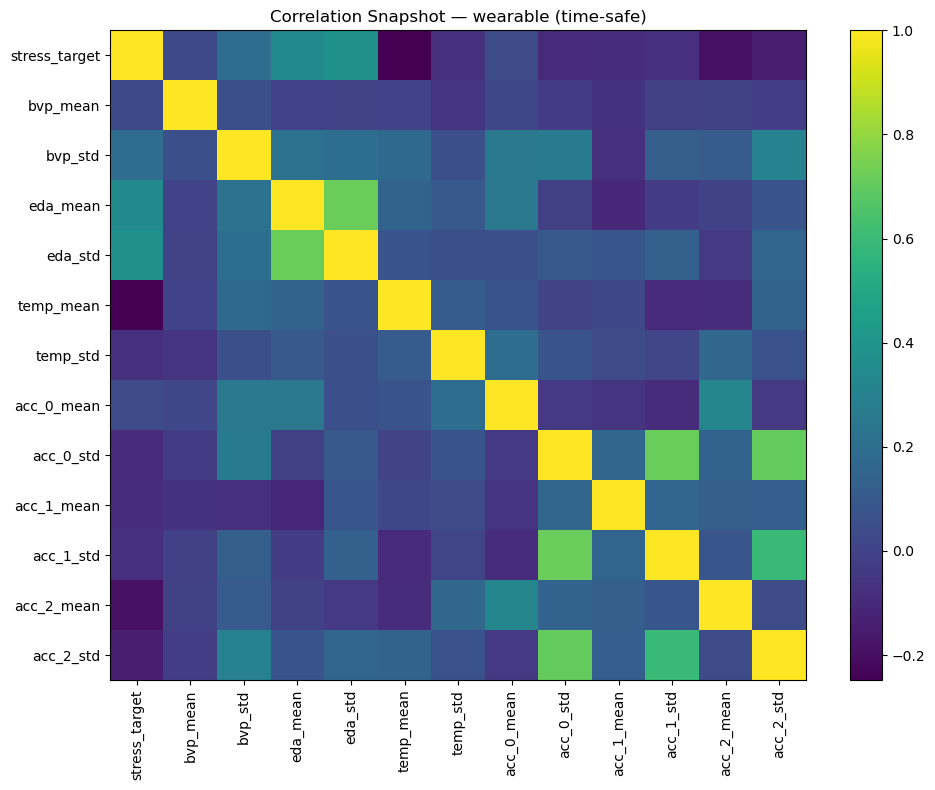

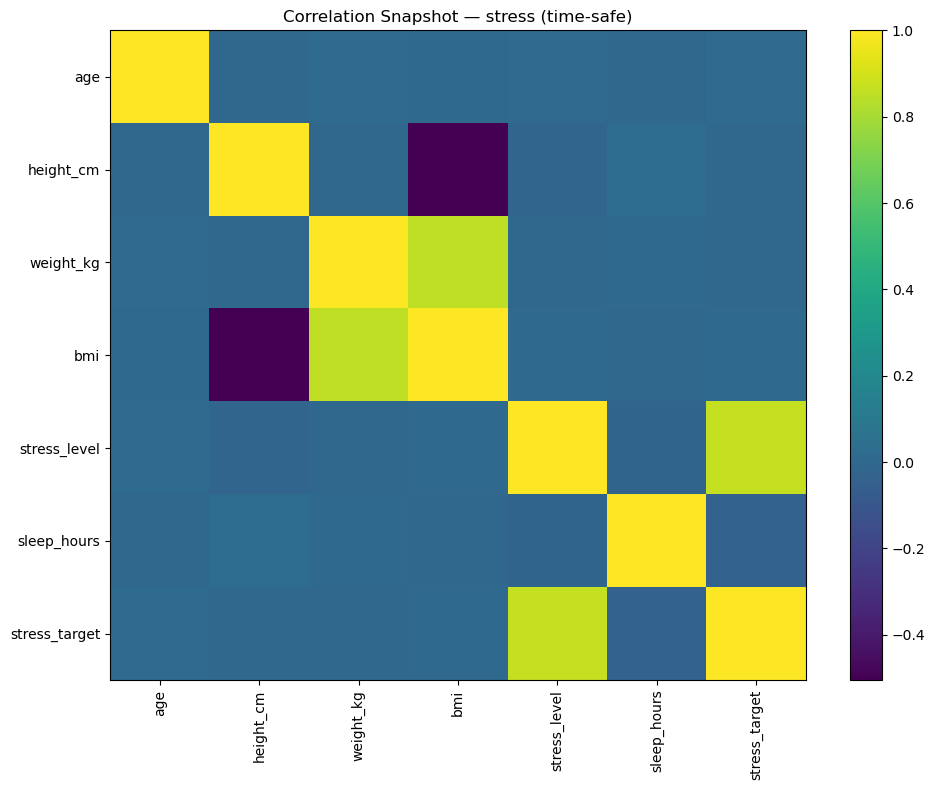

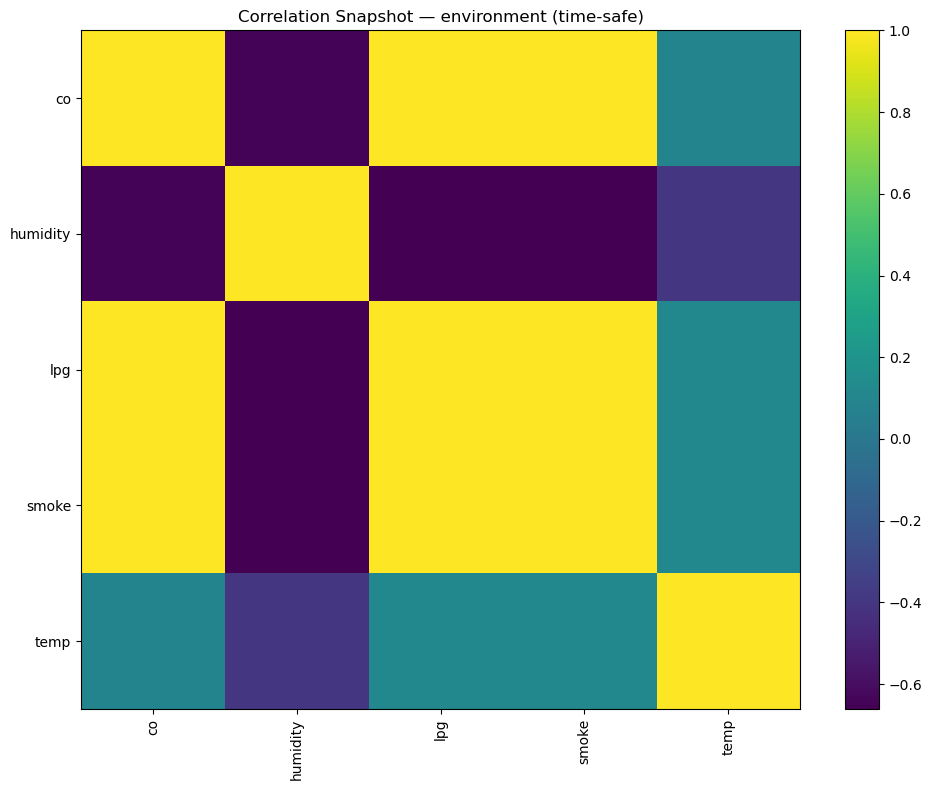


--- FEATURE ↔ TARGET CORRELATION (stress) target='stress_target' ---


,top_positive
stress_level,0.868778
height_cm,0.023978
age,0.013417
weight_kg,0.008163
bmi,-0.000741
sleep_hours,-0.009267


,top_negative
stress_level,0.868778
height_cm,0.023978
age,0.013417
weight_kg,0.008163
bmi,-0.000741
sleep_hours,-0.009267



--- FEATURE ↔ TARGET CORRELATION (wearable) target='stress_target' ---


,top_positive
eda_std,0.379667
eda_mean,0.343823
bvp_std,0.198386
acc_0_mean,0.036552
bvp_mean,0.026033
temp_std,-0.072410
acc_1_std,-0.073826
acc_1_mean,-0.091520
acc_0_std,-0.098217
acc_2_std,-0.142395


,top_negative
eda_std,0.379667
eda_mean,0.343823
bvp_std,0.198386
acc_0_mean,0.036552
bvp_mean,0.026033
temp_std,-0.072410
acc_1_std,-0.073826
acc_1_mean,-0.091520
acc_0_std,-0.098217
acc_2_std,-0.142395


[environment] No target detected.
[other] No target detected.

 MAIN EDA COMPLETE (WESAD + MODEL-SAFE).
Notes:
 - Wearable domain forced to use wesad_windows (has stress_target).
 - Time-like numeric cols (ts/timestamp) removed from variance/correlation.


In [9]:
# MAIN EDA — WESAD + MODEL-SAFE (FULL UPDATED CELL)
#    FIX 1: Wearable domain ALWAYS uses wesad_windows (not wearable_device CSV)
#    FIX 2: Environment excludes ts/timestamp from variance/corr (no dominance)
#   FIX 3: Target detection prefers stress_target
#    Safe sampling for huge datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# CONFIG

TARGET_PRIORITY = ["stress_target", "stress_level", "stresslevel", "label", "target"]

LOW_VAR_THRESH = 0.01
SAMPLE_ROWS = 3000
MAX_CORR_FEATURES = 30

# should already exist from BASIC EDA:
# processed_data: dict(domain -> list of dfs)

NON_FEATURE_COLS = {
    "id", "user_id", "subject_id", "window_id", "uuid", "index",
    "employeeid", "pid", "uid", "device_id"
}

# time-like columns to exclude from numeric analysis (very important for ENV)
TIME_LIKE_NUMERIC = {
    "ts", "timestamp", "epoch", "unix", "time", "date", "datetime",
    "ts_dt", "timestamp_dt"
}


# HELPERS

def safe_sample(df, n=SAMPLE_ROWS, seed=42):
    if df is None or df.empty:
        return df
    if df.shape[0] > n:
        return df.sample(n, random_state=seed)
    return df

def detect_target(df):
    if df is None:
        return None
    cols = list(df.columns)
    low_map = {str(c).lower(): c for c in cols}
    for t in TARGET_PRIORITY:
        if t in low_map:
            return low_map[t]
    return None

def numeric_feature_df(df):
    """
    Numeric-only dataframe excluding:
      - IDs
      - time-like numeric columns (ts/timestamp dominating variance/corr)
    """
    if df is None or df.empty:
        return pd.DataFrame()

    num = df.select_dtypes(include=[np.number]).copy()
    # drop IDs
    num = num.drop(columns=[c for c in NON_FEATURE_COLS if c in num.columns], errors="ignore")

    # drop time-like numeric columns (IMPORTANT)
    drop_time = [c for c in num.columns if str(c).lower() in TIME_LIKE_NUMERIC]
    num = num.drop(columns=drop_time, errors="ignore")

    return num

def pick_dataset(domain):
    """
     Key fix:
      - wearable domain must return WESAD windows dataframe (has stress_target)
      - others: pick largest by rows
    """
    if domain not in processed_data or not processed_data[domain]:
        return None

    if domain == "wearable":
        # Prefer dataset that actually has stress_target (wesad_windows)
        for df in processed_data[domain]:
            if isinstance(df, pd.DataFrame) and ("stress_target" in df.columns):
                return df
        # fallback: smallest (wearable_device CSV can be weird)
        return sorted(processed_data[domain], key=lambda x: x.shape[0])[0]

    # default: largest dataset for that domain
    return sorted(processed_data[domain], key=lambda x: x.shape[0], reverse=True)[0]


# 1) VARIANCE RANKING

def variance_ranking(domain):
    df = pick_dataset(domain)
    if df is None:
        print(f"[{domain}] No dataset.")
        return

    df_s = safe_sample(df, SAMPLE_ROWS)
    num = numeric_feature_df(df_s)
    if num.empty:
        print(f"[{domain}] No numeric features after exclusions.")
        return

    v = num.var(numeric_only=True).sort_values(ascending=False)

    print(f"\n--- TOP VARIANCE FEATURES ({domain}) ---")
    display(v.head(20))

    low_v = v[v < LOW_VAR_THRESH].sort_values()
    print(f"\n--- LOW VARIANCE FEATURES (< {LOW_VAR_THRESH}) ({domain}) ---")
    if len(low_v) == 0:
        print("None ")
    else:
        display(low_v.head(30))

for dom in processed_data.keys():
    variance_ranking(dom)


# 2) CORRELATION SNAPSHOT (Heatmap)

def correlation_snapshot(domain):
    df = pick_dataset(domain)
    if df is None:
        print(f"[{domain}] No dataset.")
        return

    df_s = safe_sample(df, n=min(SAMPLE_ROWS, 2000))
    num = numeric_feature_df(df_s)

    if num.shape[1] == 0:
        print(f"[{domain}] No numeric cols for correlation.")
        return

    # limit columns for readability
    if num.shape[1] > MAX_CORR_FEATURES:
        num = num.iloc[:, :MAX_CORR_FEATURES]

    corr = num.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.title(f"Correlation Snapshot — {domain} (time-safe)")
    plt.xticks(range(corr.shape[1]), corr.columns, rotation=90)
    plt.yticks(range(corr.shape[0]), corr.index)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

for dom in ["wearable", "stress", "environment"]:
    if dom in processed_data:
        correlation_snapshot(dom)


# 3) FEATURE ↔ TARGET CORRELATION

def feature_target_corr(domain):
    df = pick_dataset(domain)
    if df is None:
        print(f"[{domain}] No dataset.")
        return

    df_s = safe_sample(df, SAMPLE_ROWS)
    target = detect_target(df_s)

    if not target:
        print(f"[{domain}] No target detected.")
        return

    # y must be numeric
    y = pd.to_numeric(df_s[target], errors="coerce")
    if y.notna().sum() < 30:
        print(f"[{domain}] Target '{target}' not numeric enough for correlation.")
        return

    num = numeric_feature_df(df_s)
    if target in num.columns:
        num = num.drop(columns=[target], errors="ignore")

    if num.empty:
        print(f"[{domain}] No numeric features to correlate.")
        return

    corr = num.corrwith(y).sort_values(ascending=False)

    print(f"\n--- FEATURE ↔ TARGET CORRELATION ({domain}) target='{target}' ---")
    display(pd.DataFrame({"top_positive": corr.head(15)}))
    display(pd.DataFrame({"top_negative": corr.tail(15)}))

for dom in processed_data.keys():
    feature_target_corr(dom)

print("\n MAIN EDA COMPLETE (WESAD + MODEL-SAFE).")
print("Notes:")
print(" - Wearable domain forced to use wesad_windows (has stress_target).")
print(" - Time-like numeric cols (ts/timestamp) removed from variance/correlation.")

In [14]:
# feature selection

In [10]:

#  FEATURE SELECTION (Project-aligned)  UPDATED
#    Base wearable = wesad_windows (has stress_target)
#    Keep wearable: mean/std only (+ auto drop near-constant temp_std)
#    Keep env: co/temp/humidity/pm/no2/o3/so2/noise etc (numeric only)
#    Drops time-like + id-like cols safely

# CONFIG

ID_DROP = {"id","user_id","uid","pid","device_id","uuid","post_id","sentence_range"}
KEEP_SUBJECT = {"subject_id"}  # keep for group split

ENV_KEYWORDS = [
    "co","humidity","temp","temperature","pm","pm2","pm2_5","pm10","no2","o3","so2","aqi",
    "noise","db","decibel","sound","pressure","wind","precip","cloud","visibility","weather_code"
]

TIME_DROP_HINTS = [
    "ts", "timestamp", "time", "date", "datetime", "epoch", "unix"
]

selected_data = {}


# Wearable (WESAD windows)

def select_wearable_wesad(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # must-have cols
    must = ["subject_id", "stress_target"]
    for c in must:
        if c not in df.columns:
            raise KeyError(f"Missing required column '{c}' in wesad_windows")

    keep = ["subject_id"]
    if "window_id" in df.columns:
        keep.append("window_id")
    keep.append("stress_target")

    # keep only mean/std features
    feat_cols = []
    for c in df.columns:
        cl = str(c).lower()
        if cl.endswith("_mean") or cl.endswith("_std"):
            feat_cols.append(c)

    keep = keep + feat_cols
    keep = [c for c in keep if c in df.columns]

    out = df[keep].copy()

    #  auto-drop near-constant temp_std (from your variance output)
    if "temp_std" in out.columns:
        if out["temp_std"].nunique(dropna=True) <= 3 or out["temp_std"].std() < 1e-3:
            out = out.drop(columns=["temp_std"])
            print("🧹 Dropped near-constant wearable feature: temp_std")

    return out

# ------------------------
# Environment selector
# -------------------------
def select_environment(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # drop id cols
    df = df.drop(columns=list(ID_DROP), errors="ignore")

    # drop time-like cols (including *_dt)
    drop_time = []
    for c in df.columns:
        cl = str(c).lower()
        if cl.endswith("_dt"):
            drop_time.append(c)
        if any(h == cl or h in cl for h in TIME_DROP_HINTS):
            drop_time.append(c)
    df = df.drop(columns=list(set(drop_time)), errors="ignore")

    # keep numeric only
    num = df.select_dtypes(include=[np.number]).copy()
    if num.empty:
        return num

    # keyword filter on numeric cols
    keep = []
    for c in num.columns:
        cl = str(c).lower()
        if any(k in cl for k in ENV_KEYWORDS):
            keep.append(c)

    # fallback: if no keyword match, keep all numeric
    if len(keep) == 0:
        keep = num.columns.tolist()

    # de-dup
    keep = list(dict.fromkeys(keep))
    return num[keep].copy()

# -------------------------
# Apply selections
# -------------------------
selected_data["wesad_windows"] = select_wearable_wesad(clean_data["wesad_windows"])

for env_name in ["environmental_sensor", "noise_india", "pollution_india", "weather_air_quality"]:
    if env_name in clean_data and isinstance(clean_data[env_name], pd.DataFrame):
        selected_data[env_name] = select_environment(clean_data[env_name])

print("\n Selected datasets ready")
for k, v in selected_data.items():
    print(f"{k:20s} -> {v.shape}")


 Selected datasets ready
wesad_windows        -> (654, 15)
environmental_sensor -> (405171, 3)
noise_india          -> (5005, 6)
pollution_india      -> (824, 3)
weather_air_quality  -> (72, 15)


In [11]:
# train test split

In [12]:

# 6) TRAIN/TEST SPLIT (Wearable Only - FIXED DEFINITIONS)
#    Group split by subject_id 
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# --- DEFINE MISSING VARIABLES ---
# 1. Identify feature columns (everything except ID and target)
ignore_cols = {'subject_id', 'window_id', 'stress_target'}
feature_cols = [c for c in clean_data['wesad_windows'].columns if c not in ignore_cols]

# 2. Assign X, y, and groups
X_wear_model = clean_data['wesad_windows'][feature_cols]
y = clean_data['wesad_windows']['stress_target'].values
groups = clean_data['wesad_windows']['subject_id'].values

# Now we can safely copy
X = X_wear_model.copy()

# --- PERFORM SPLIT ---
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

# Use next() on the generator to get indices
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y[train_idx]
y_test  = y[test_idx]

# --- OUTPUT LOGS ---
print("Group split done (by subject_id)")
print(f"Train shape: {X_train.shape}")
print(f"Test shape : {X_test.shape}")

print("\nTrain subjects:", len(np.unique(groups[train_idx])))
print("Test subjects :", len(np.unique(groups[test_idx])))

print("\nClass balance (train):")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, np.round(counts / counts.sum(), 3))))

print("\nClass balance (test):")
unique, counts = np.unique(y_test, return_counts=True)
print(dict(zip(unique, np.round(counts / counts.sum(), 3))))

Group split done (by subject_id)
Train shape: (522, 12)
Test shape : (132, 12)

Train subjects: 12
Test subjects : 3

Class balance (train):
{np.int64(0): np.float64(0.5), np.int64(1): np.float64(0.5)}

Class balance (test):
{np.int64(0): np.float64(0.5), np.int64(1): np.float64(0.5)}


In [13]:

# PREPROCESSOR 
#    Wearable-only features
#    Numeric only
#    Median imputation
#    Standard scaling
#    Ready for Pipeline


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np


# 1) Identify numeric columns (from wearable split)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Sanity check
print("Feature count (should be 12):", len(num_cols))


# 2) Numeric pipeline

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# 3) ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols)
    ],
    remainder="drop"
)

print("\n Preprocessor ready (Wearable – Classification)")
print("Columns used:")
print(num_cols)

Feature count (should be 12): 12

 Preprocessor ready (Wearable – Classification)
Columns used:
['bvp_mean', 'bvp_std', 'eda_mean', 'eda_std', 'temp_mean', 'temp_std', 'acc_0_mean', 'acc_0_std', 'acc_1_mean', 'acc_1_std', 'acc_2_mean', 'acc_2_std']


In [14]:
#ml models

In [15]:
# random forest

In [16]:

# RANDOM FOREST 

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf) * 100
f1_rf = f1_score(y_test, y_pred_rf) * 100
auc_rf = roc_auc_score(y_test, y_prob_rf) * 100

print("RANDOM FOREST RESULTS")
print(f"Accuracy : {acc_rf:.2f} %")
print(f"F1 Score : {f1_rf:.2f} %")
print(f"ROC AUC  : {auc_rf:.2f} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy : 96.21 %
F1 Score : 96.30 %
ROC AUC  : 99.27 %
Confusion Matrix:
 [[62  4]
 [ 1 65]]


In [17]:
# xg boost

In [18]:
# XGBOOST CLASSIFIER

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline

xgb_model = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb) * 100
f1_xgb = f1_score(y_test, y_pred_xgb) * 100
auc_xgb = roc_auc_score(y_test, y_prob_xgb) * 100

print("XGBOOST RESULTS")
print(f"Accuracy : {acc_xgb:.2f} %")
print(f"F1 Score : {f1_xgb:.2f} %")
print(f"ROC AUC  : {auc_xgb:.2f} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

XGBOOST RESULTS
Accuracy : 92.42 %
F1 Score : 92.54 %
ROC AUC  : 98.05 %
Confusion Matrix:
 [[60  6]
 [ 4 62]]


In [19]:
#logistic regression

In [20]:
# LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

lr_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr) * 100
f1_lr = f1_score(y_test, y_pred_lr) * 100
auc_lr = roc_auc_score(y_test, y_prob_lr) * 100

print("LOGISTIC REGRESSION RESULTS")
print(f"Accuracy : {acc_lr:.2f} %")
print(f"F1 Score : {f1_lr:.2f} %")
print(f"ROC AUC  : {auc_lr:.2f} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy : 84.09 %
F1 Score : 86.27 %
ROC AUC  : 81.27 %
Confusion Matrix:
 [[45 21]
 [ 0 66]]


In [21]:
#svm

In [22]:
# SVM (RBF) CLASSIFIER

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline

svm_model = Pipeline([
    ("prep", preprocessor),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm) * 100
f1_svm = f1_score(y_test, y_pred_svm) * 100
auc_svm = roc_auc_score(y_test, y_prob_svm) * 100

print("SVM RESULTS")
print(f"Accuracy : {acc_svm:.2f} %")
print(f"F1 Score : {f1_svm:.2f} %")
print(f"ROC AUC  : {auc_svm:.2f} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM RESULTS
Accuracy : 93.18 %
F1 Score : 93.23 %
ROC AUC  : 96.92 %
Confusion Matrix:
 [[61  5]
 [ 4 62]]


In [23]:
#GRADIENT BOOSTING

In [24]:
# GRADIENT BOOSTING CLASSIFIER

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

gb_model = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb) * 100
f1_gb = f1_score(y_test, y_pred_gb) * 100
auc_gb = roc_auc_score(y_test, y_prob_gb) * 100

print("GRADIENT BOOSTING RESULTS")
print(f"Accuracy : {acc_gb:.2f} %")
print(f"F1 Score : {f1_gb:.2f} %")
print(f"ROC AUC  : {auc_gb:.2f} %")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

GRADIENT BOOSTING RESULTS
Accuracy : 94.70 %
F1 Score : 94.89 %
ROC AUC  : 96.30 %
Confusion Matrix:
 [[60  6]
 [ 1 65]]


In [25]:
# FINAL COMPARISON SUMMARY

# Create a list of results using the variables defined in your previous cells
comparison_data = [
    ("RandomForest",       acc_rf,  f1_rf,  auc_rf),
    ("XGBoost",            acc_xgb, f1_xgb, auc_xgb),
    ("GradientBoosting",   acc_gb,  f1_gb,  auc_gb),
    ("SVM",                acc_svm, f1_svm, auc_svm),
    ("LogisticRegression", acc_lr,  f1_lr,  auc_lr)
]

print("FINAL COMPARISON:")
print("-" * 65)

for name, acc, f1, auc in comparison_data:
    # This prints the name left-aligned (20 spaces) followed by the metrics
    print(f"{name:20} Accuracy={acc:.2f}%   F1={f1:.2f}%   AUC={auc:.2f}%")

print("-" * 65)

FINAL COMPARISON:
-----------------------------------------------------------------
RandomForest         Accuracy=96.21%   F1=96.30%   AUC=99.27%
XGBoost              Accuracy=92.42%   F1=92.54%   AUC=98.05%
GradientBoosting     Accuracy=94.70%   F1=94.89%   AUC=96.30%
SVM                  Accuracy=93.18%   F1=93.23%   AUC=96.92%
LogisticRegression   Accuracy=84.09%   F1=86.27%   AUC=81.27%
-----------------------------------------------------------------


In [26]:
# cross validation

In [27]:


# GROUP CROSS-VALIDATION FOR ALL MODELS

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score
import numpy as np

gkf = GroupKFold(n_splits=5)

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced"
    ),
    
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    )
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(
        pipe,
        X,
        y,
        groups=groups,
        cv=gkf,
        scoring="accuracy",
        n_jobs=-1
    )
    
    results[name] = {
        "mean_accuracy": scores.mean() * 100,
        "std": scores.std() * 100
    }
    
    print(f"\n{name}")
    print("Fold Accuracies:", np.round(scores * 100, 2))
    print("Mean:", round(scores.mean() * 100, 2), "%")
    print("Std :", round(scores.std() * 100, 2), "%")

print("\n\nFINAL COMPARISON:")
for k, v in results.items():
    print(f"{k:20s}  Mean={v['mean_accuracy']:.2f}%   Std={v['std']:.2f}%")


RandomForest
Fold Accuracies: [78.03 68.18 86.15 79.23 83.08]
Mean: 78.93 %
Std : 6.1 %

XGBoost
Fold Accuracies: [76.52 75.76 74.62 82.31 83.08]
Mean: 78.45 %
Std : 3.52 %

GradientBoosting
Fold Accuracies: [81.82 70.45 74.62 83.85 83.08]
Mean: 78.76 %
Std : 5.29 %

SVM
Fold Accuracies: [84.85 67.42 90.77 70.77 73.08]
Mean: 77.38 %
Std : 8.9 %

LogisticRegression
Fold Accuracies: [82.58 55.3  73.85 77.69 50.77]
Mean: 68.04 %
Std : 12.64 %


FINAL COMPARISON:
RandomForest          Mean=78.93%   Std=6.10%
XGBoost               Mean=78.45%   Std=3.52%
GradientBoosting      Mean=78.76%   Std=5.29%
SVM                   Mean=77.38%   Std=8.90%
LogisticRegression    Mean=68.04%   Std=12.64%


In [28]:
# FEATURE IMPORTANCE (XGBoost Final Model)

import matplotlib.pyplot as plt

# Train final XGBoost on full dataset
final_model = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ))
])

final_model.fit(X, y)

# Extract feature importance
model = final_model.named_steps["model"]
importances = model.feature_importances_

features = X.columns

feat_imp = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)

print("Top 10 Most Important Features:")
for f, v in feat_imp[:10]:
    print(f"{f:15s}  {v:.4f}")

Top 10 Most Important Features:
eda_std          0.2392
temp_mean        0.1484
eda_mean         0.1475
acc_0_mean       0.0960
acc_1_mean       0.0780
bvp_std          0.0716
temp_std         0.0681
acc_2_mean       0.0654
acc_2_std        0.0295
acc_1_std        0.0245


In [29]:
# post EDA

=========== XGBOOST EDA REPORT ===========
Train shape: (522, 12) | Test shape: (132, 12)
Features: 12
Feature names: ['bvp_mean', 'bvp_std', 'eda_mean', 'eda_std', 'temp_mean', 'temp_std', 'acc_0_mean', 'acc_0_std', 'acc_1_mean', 'acc_1_std', 'acc_2_mean', 'acc_2_std']

--- METRICS ---
Accuracy : 90.91 %
F1 Score : 90.91 %
ROC AUC  : 97.98 %
Confusion Matrix:
 [[60  6]
 [ 6 60]]


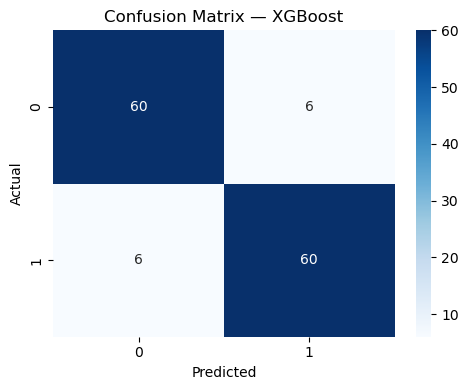

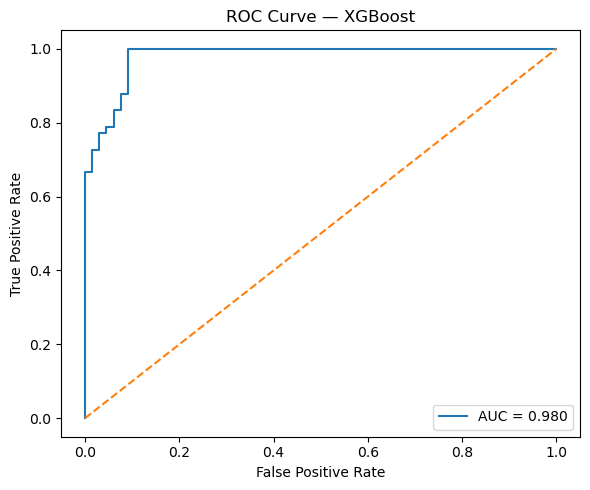

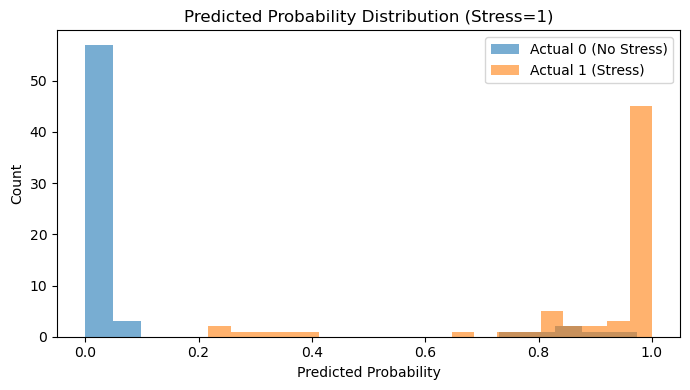


--- FEATURE IMPORTANCE ---


,feature,gain_importance,split_count
2,eda_mean,6.080049,353.0
4,temp_mean,4.509210,413.0
1,bvp_std,2.398808,230.0
8,acc_1_mean,2.134999,300.0
3,eda_std,1.769024,142.0
10,acc_2_mean,1.721656,283.0
5,temp_std,1.608739,167.0
6,acc_0_mean,1.525842,180.0
11,acc_2_std,0.907843,96.0
7,acc_0_std,0.784711,74.0


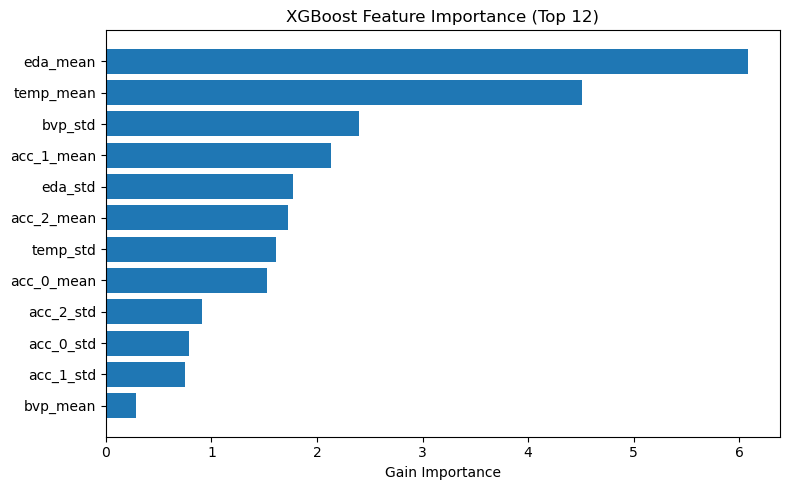


--- ERROR ANALYSIS ---
Wrong predictions: 12 out of 132


,y_true,y_pred,p_stress,abs_margin_from_0_5,wrong
93,0,1,0.974426,0.474426,1
105,0,1,0.925651,0.425651,1
97,0,1,0.876813,0.376813,1
127,0,1,0.843930,0.343930,1
103,0,1,0.823112,0.323112,1
23,1,0,0.217388,0.282612,1
124,0,1,0.749318,0.249318,1
37,1,0,0.251196,0.248804,1
120,1,0,0.267155,0.232845,1
2,1,0,0.297546,0.202454,1


,bvp_mean,bvp_std,eda_mean,eda_std,temp_mean,temp_std,acc_0_mean,acc_0_std,acc_1_mean,acc_1_std,acc_2_mean,acc_2_std,y_true,y_pred,p_stress
487,-0.188229,26.960788,2.149718,0.180071,31.629000,0.054824,57.218229,5.545717,1.572396,4.657875,19.407812,16.549479,0,1,0.974426
499,-0.225891,27.420342,1.213219,0.123238,32.123167,0.055931,56.977604,4.142767,4.054167,3.678652,24.665625,9.039823,0,1,0.925651
491,-0.564742,25.569182,1.421373,0.119582,32.021833,0.064472,55.519792,4.645296,3.715625,3.695488,27.324479,10.065174,0,1,0.876813
521,0.039555,17.692422,0.759516,0.045590,32.690250,0.114335,48.500521,2.171549,-2.694792,0.789629,39.746354,2.516143,0,1,0.843930
497,0.115018,46.202935,2.373327,0.114752,31.526833,0.065726,31.953646,28.945629,18.275000,23.119423,30.159375,19.904345,0,1,0.823112
23,0.192909,54.228126,2.186846,0.060678,34.034750,0.034095,57.860937,6.207517,-19.920833,5.063861,-12.418229,7.175812,1,0,0.217388
518,0.130120,50.286755,2.600919,0.191971,31.399500,0.079371,25.091667,27.074991,18.433854,25.073596,38.784375,14.773335,0,1,0.749318
37,-0.391497,85.406003,2.307275,0.092715,34.087500,0.035783,57.000521,7.952692,-19.206771,6.069515,-13.920312,11.136623,1,0,0.251196
514,-0.062070,40.337161,8.242373,0.354891,33.468500,0.025385,56.405729,11.677100,-9.030208,7.468972,13.530729,18.915797,1,0,0.267155
2,-0.002880,47.190402,3.085502,0.137465,33.768083,0.031958,58.865625,3.805378,-21.513542,2.800451,-3.925000,3.923434,1,0,0.297546



--- SHAP SUMMARY (Global Explainability) ---


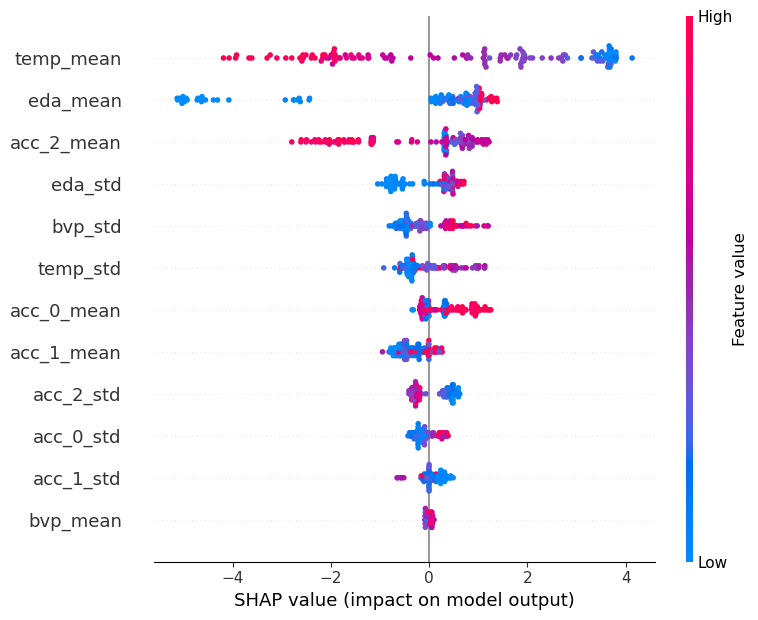


 XGBoost EDA done.


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)

# Optional (pretty heatmap)
try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

# Optional SHAP
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

#  Checks

needed = ["xgb_model", "X_train", "X_test", "y_train", "y_test"]
missing = [k for k in needed if k not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}")

if not hasattr(xgb_model, "named_steps") or "model" not in xgb_model.named_steps:
    raise TypeError("xgb_model must be a Pipeline with a 'model' step (XGBClassifier).")

clf = xgb_model.named_steps["model"]
feat_names = list(X_train.columns)

print("=========== XGBOOST EDA REPORT ===========")
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Features:", len(feat_names))
print("Feature names:", feat_names)



#  Predictions + metrics

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred) * 100
f1  = f1_score(y_test, y_pred) * 100
auc_score = roc_auc_score(y_test, y_prob) * 100
cm = confusion_matrix(y_test, y_pred)

print("\n--- METRICS ---")
print(f"Accuracy : {acc:.2f} %")
print(f"F1 Score : {f1:.2f} %")
print(f"ROC AUC  : {auc_score:.2f} %")
print("Confusion Matrix:\n", cm)



#  Confusion Matrix plot

plt.figure(figsize=(5, 4))
if HAS_SEABORN:
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
else:
    plt.imshow(cm)
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.colorbar()
plt.title("Confusion Matrix — XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



# 3) ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve — XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()



# 4) Probability distributions

y_test_arr = np.array(y_test)

plt.figure(figsize=(7, 4))
plt.hist(y_prob[y_test_arr == 0], bins=20, alpha=0.6, label="Actual 0 (No Stress)")
plt.hist(y_prob[y_test_arr == 1], bins=20, alpha=0.6, label="Actual 1 (Stress)")
plt.title("Predicted Probability Distribution (Stress=1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


# 5) Feature importance
#    Prefer Booster gain/weight if available (best for XGBoost)

print("\n--- FEATURE IMPORTANCE ---")
imp_df = None

try:
    booster = clf.get_booster()
    score_gain = booster.get_score(importance_type="gain")
    score_weight = booster.get_score(importance_type="weight")  # split counts

    # XGBoost uses f0,f1,... mapping (Column order AFTER preprocessing)
    # Your preprocessor is numeric-only passthrough+scaler so ordering == feat_names
    gain = np.array([score_gain.get(f"f{i}", 0.0) for i in range(len(feat_names))], dtype=float)
    weight = np.array([score_weight.get(f"f{i}", 0.0) for i in range(len(feat_names))], dtype=float)

    imp_df = pd.DataFrame({
        "feature": feat_names,
        "gain_importance": gain,
        "split_count": weight
    }).sort_values("gain_importance", ascending=False)

except Exception:
    # fallback to sklearn-style
    if hasattr(clf, "feature_importances_"):
        gain = clf.feature_importances_
        imp_df = pd.DataFrame({"feature": feat_names, "importance": gain}).sort_values("importance", ascending=False)

if imp_df is not None:
    display(imp_df.head(12))

    # plot top 12
    top = imp_df.head(12).copy()
    plt.figure(figsize=(8, 5))
    if "gain_importance" in top.columns:
        top = top.sort_values("gain_importance")
        plt.barh(top["feature"], top["gain_importance"])
        plt.xlabel("Gain Importance")
    else:
        top = top.sort_values("importance")
        plt.barh(top["feature"], top["importance"])
        plt.xlabel("Importance")
    plt.title("XGBoost Feature Importance (Top 12)")
    plt.tight_layout()
    plt.show()
else:
    print(" Could not extract feature importance.")


# 6) Error analysis (show top wrong predictions)

err = pd.DataFrame({
    "y_true": y_test_arr,
    "y_pred": y_pred,
    "p_stress": y_prob
})
err["abs_margin_from_0_5"] = np.abs(err["p_stress"] - 0.5)
err["wrong"] = (err["y_true"] != err["y_pred"]).astype(int)

wrong_df = err[err["wrong"] == 1].copy()
print("\n--- ERROR ANALYSIS ---")
print("Wrong predictions:", len(wrong_df), "out of", len(err))

if len(wrong_df) > 0:
    # show most confident wrong (largest distance from 0.5)
    wrong_df = wrong_df.sort_values("abs_margin_from_0_5", ascending=False).head(15)
    display(wrong_df)

    # also show corresponding feature rows
    idx_wrong = wrong_df.index
    display(X_test.iloc[idx_wrong].assign(y_true=err.loc[idx_wrong, "y_true"].values,
                                         y_pred=err.loc[idx_wrong, "y_pred"].values,
                                         p_stress=err.loc[idx_wrong, "p_stress"].values))
else:
    print(" No wrong predictions in this test split.")


# 7) SHAP (optional)

if HAS_SHAP:
    try:
        # Need model input space: after preprocessor
        X_test_trans = xgb_model.named_steps["prep"].transform(X_test)

        # Make dense if sparse
        try:
            X_dense = X_test_trans.toarray()
        except Exception:
            X_dense = np.array(X_test_trans)

        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_dense)

        print("\n--- SHAP SUMMARY (Global Explainability) ---")
        shap.summary_plot(shap_values, X_dense, feature_names=feat_names)

    except Exception as e:
        print("\n SHAP failed:", e)
        print("Tip: pip install shap")
else:
    print("\n SHAP not installed (skip). Install with: pip install shap")

print("\n XGBoost EDA done.")

In [31]:
#cluster evaluation

===== CLUSTER EVALUATION (TRAIN ONLY) =====
k_values      : [2, 3, 4, 5, 6, 7, 8, 9, 10]
silhouette    : [0.1768, 0.1794, 0.1588, 0.1663, 0.1605, 0.1831, 0.1736, 0.1869, 0.1948]
best_k (sil)  : 10

Cluster → stress_target distribution (row-normalized):


stress_target,0,1
cluster,,
0,0.843,0.157
1,0.870,0.130
2,0.316,0.684
3,0.121,0.879
4,0.506,0.494
5,0.500,0.500
6,1.000,0.000
7,0.000,1.000
8,0.500,0.500


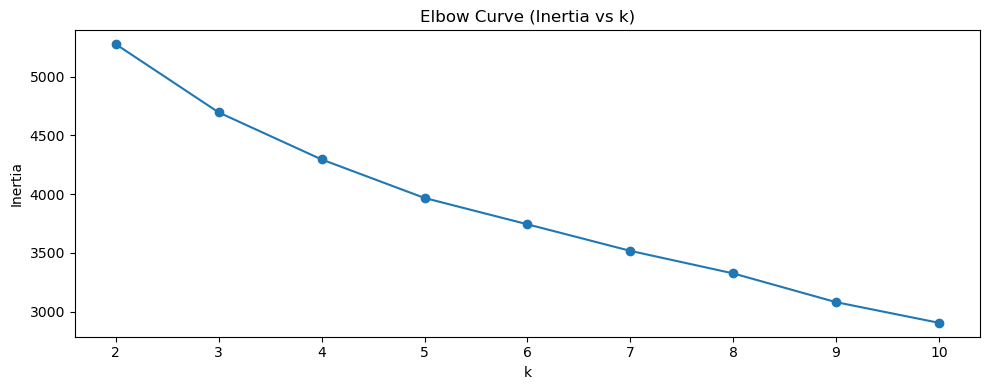

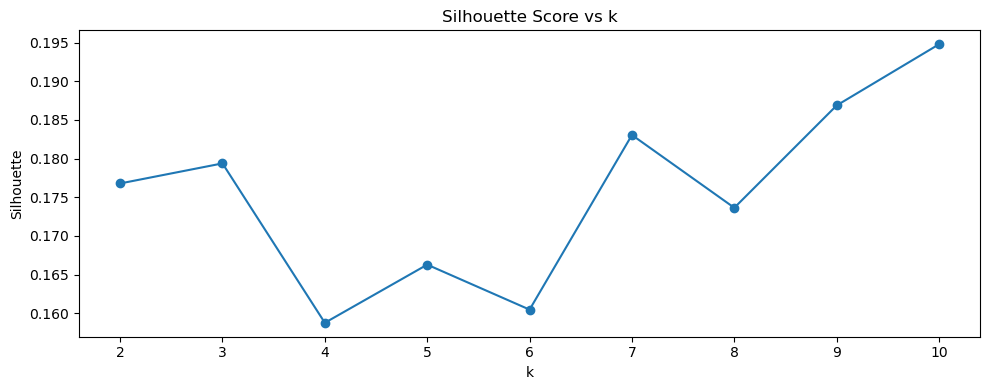

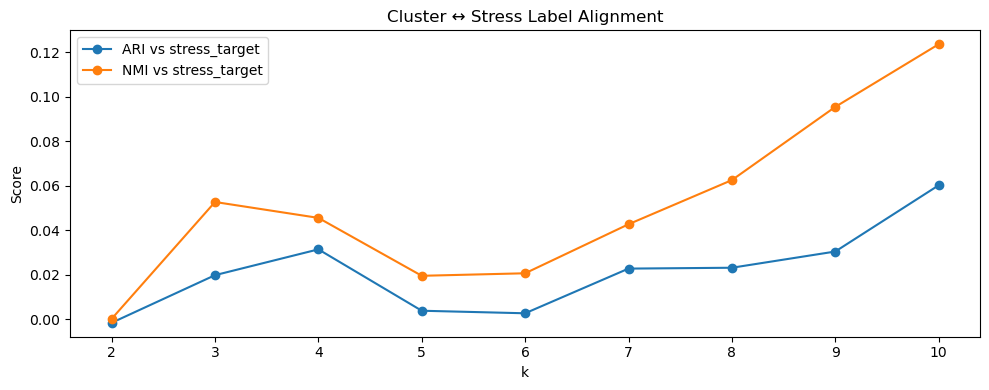

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score


# 0) Pick data (use TRAIN only)

Xc = X_train.copy()
yc = y_train.copy()

# 1) Simple scaler pipeline (no leakage)

prep_cluster = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Xc_z = prep_cluster.fit_transform(Xc)


# 2) Evaluate multiple k

k_values = list(range(2, 11))
inertias = []
sil_scores = []
ari_scores = []
nmi_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xc_z)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xc_z, labels))

    # how much clusters align with stress labels (not mandatory, but useful)
    ari_scores.append(adjusted_rand_score(yc, labels))
    nmi_scores.append(normalized_mutual_info_score(yc, labels))

# pick best k by silhouette
best_k = k_values[int(np.argmax(sil_scores))]

print("===== CLUSTER EVALUATION (TRAIN ONLY) =====")
print("k_values      :", k_values)
print("silhouette    :", np.round(sil_scores, 4).tolist())
print("best_k (sil)  :", best_k)

# -----------------------------
# 3) Fit best_k & analyze
# -----------------------------
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cl_best = km_best.fit_predict(Xc_z)

ct = pd.crosstab(pd.Series(cl_best, name="cluster"),
                 pd.Series(yc, name="stress_target"),
                 normalize="index").round(3)

print("\nCluster → stress_target distribution (row-normalized):")
display(ct)

# -----------------------------
# 4) Plots
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Curve (Inertia vs k)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(k_values, sil_scores, marker="o")
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(k_values, ari_scores, marker="o", label="ARI vs stress_target")
plt.plot(k_values, nmi_scores, marker="o", label="NMI vs stress_target")
plt.title("Cluster ↔ Stress Label Alignment")
plt.xlabel("k")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
#visualization

========== XGBOOST UPDATED REPORT ==========
Train shape: (522, 12) | Test shape: (132, 12)
Features: 12

--- METRICS (Holdout) ---
Accuracy : 93.94 %
F1 Score : 94.12 %
ROC AUC  : 97.98 %
LogLoss  : 0.1597

--- CORRELATION HEATMAP (EDA) ---


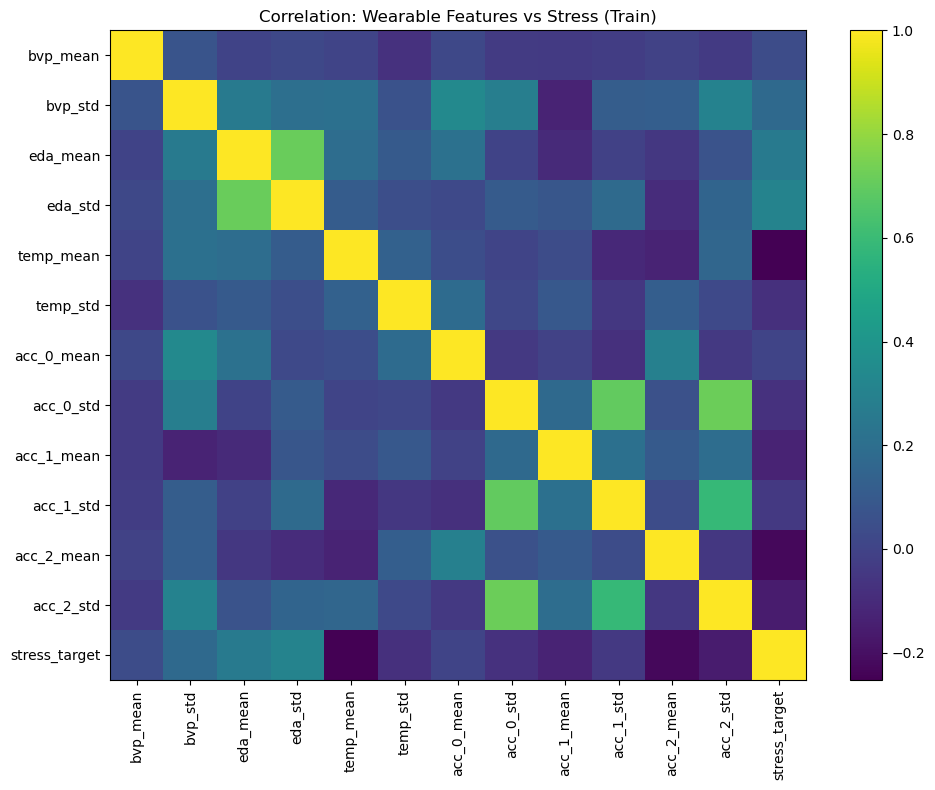


--- RELIABILITY (StratifiedGroupKFold ROC-AUC) ---
Fold ROC-AUC: [0.7893 0.5608 0.74   0.9984 0.9151]
Mean ROC-AUC : 0.8007
Std Dev      : 0.1507


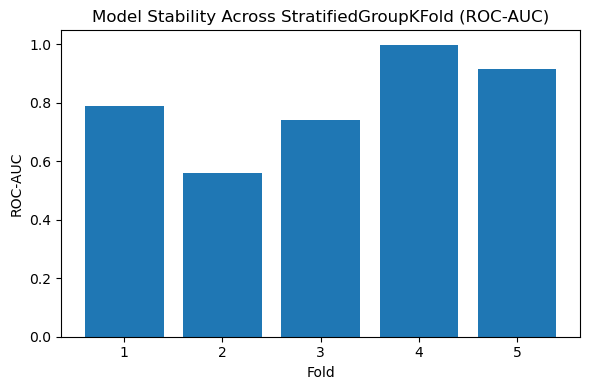


--- Fold Class Distribution (StratifiedGroupKFold) ---


,fold,val_samples,val_1(stress),val_0(no),val_pos_rate
0,1,130,65,65,0.5
1,2,86,43,43,0.5
2,3,134,67,67,0.5
3,4,86,43,43,0.5
4,5,86,43,43,0.5



--- LEARNING CURVES (ROC-AUC + LogLoss) ---


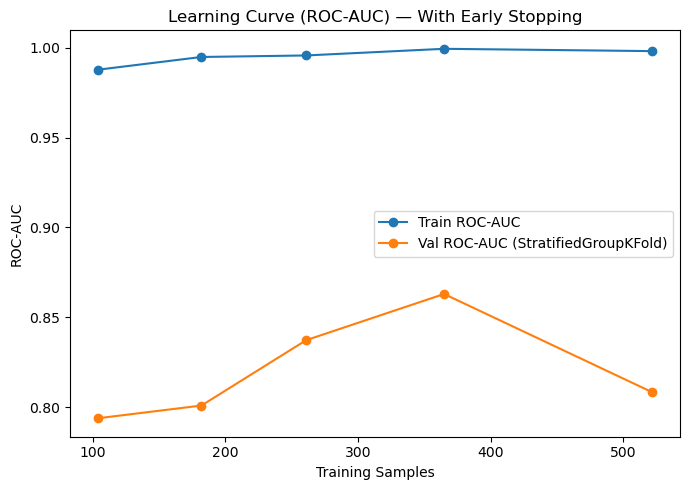

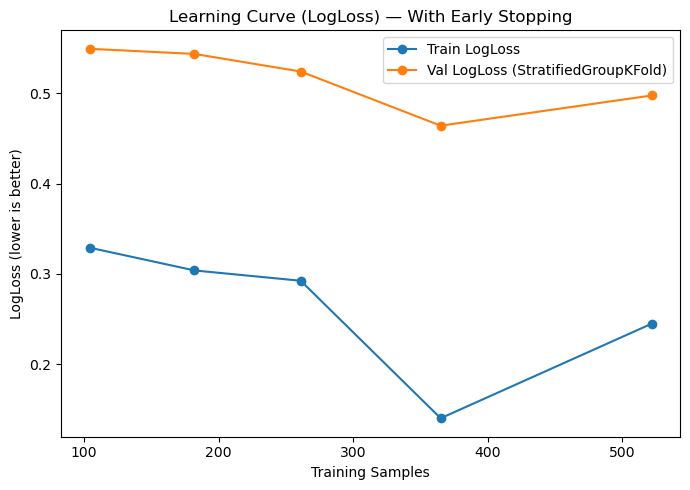

,train_size,train_auc,val_auc,train_logloss,val_logloss
0,104,0.987711,0.793927,0.329147,0.549511
1,182,0.994787,0.800989,0.303869,0.543823
2,261,0.995636,0.837336,0.292433,0.524312
3,365,0.999330,0.863012,0.140054,0.464313
4,522,0.998044,0.808379,0.244942,0.497791


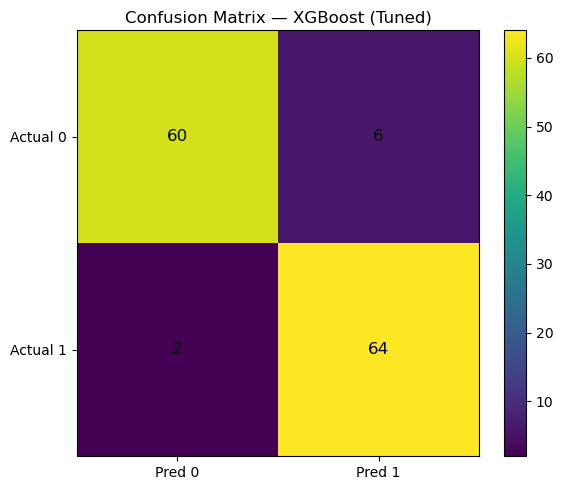

Confusion Matrix:
 [[60  6]
 [ 2 64]]


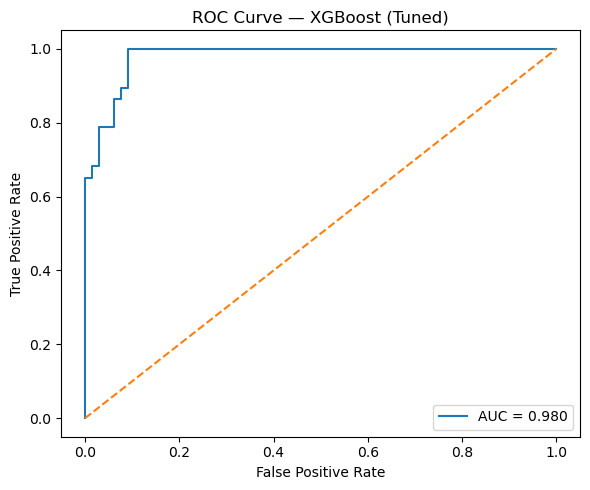

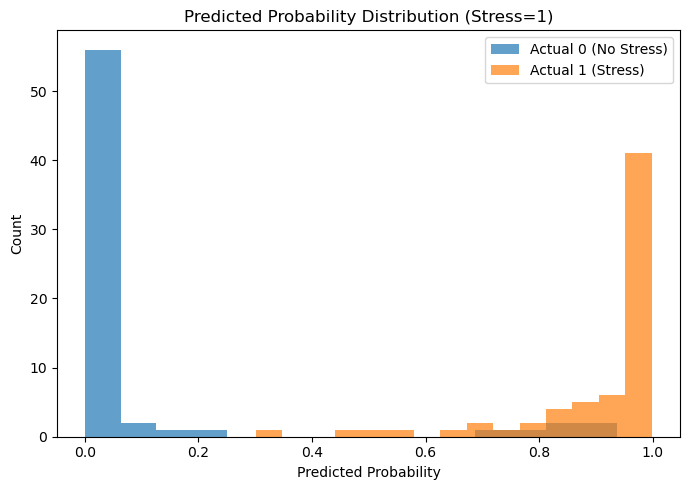

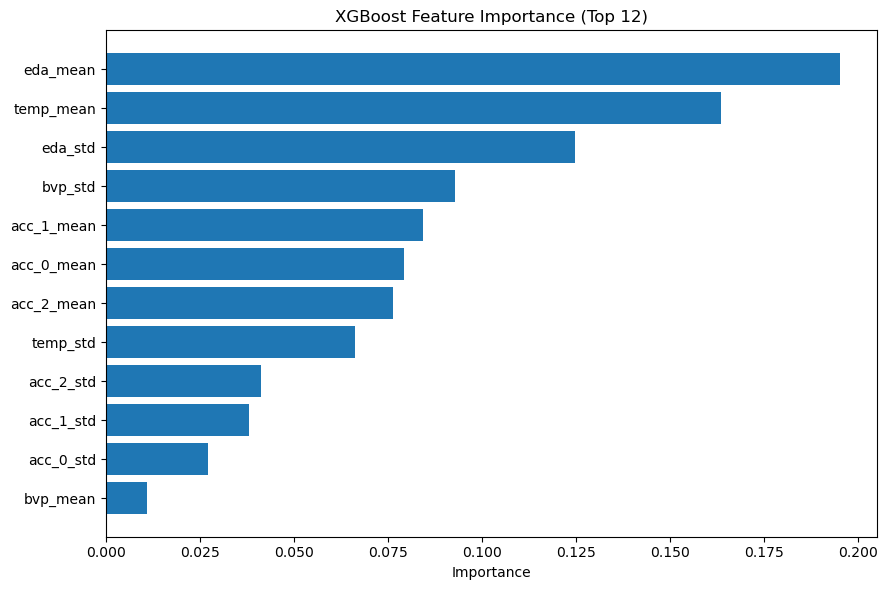


--- FEATURE IMPORTANCE (Top 12) ---


,feature,importance
2,eda_mean,0.195227
4,temp_mean,0.163542
3,eda_std,0.124675
1,bvp_std,0.092929
8,acc_1_mean,0.084277
6,acc_0_mean,0.079308
10,acc_2_mean,0.076403
5,temp_std,0.066274
11,acc_2_std,0.041129
9,acc_1_std,0.038138



--- ERROR ANALYSIS ---
Wrong predictions: 8 out of 132


,bvp_mean,bvp_std,eda_mean,eda_std,temp_mean,temp_std,acc_0_mean,acc_0_std,acc_1_mean,acc_1_std,acc_2_mean,acc_2_std,y_true,y_pred,p_stress,abs_margin_from_0_5,wrong
487,-0.188229,26.960788,2.149718,0.180071,31.629000,0.054824,57.218229,5.545717,1.572396,4.657875,19.407812,16.549479,0,1,0.937985,0.437985,1
499,-0.225891,27.420342,1.213219,0.123238,32.123167,0.055931,56.977604,4.142767,4.054167,3.678652,24.665625,9.039823,0,1,0.921399,0.421399,1
521,0.039555,17.692422,0.759516,0.045590,32.690250,0.114335,48.500521,2.171549,-2.694792,0.789629,39.746354,2.516143,0,1,0.872634,0.372634,1
491,-0.564742,25.569182,1.421373,0.119582,32.021833,0.064472,55.519792,4.645296,3.715625,3.695488,27.324479,10.065174,0,1,0.870786,0.370786,1
497,0.115018,46.202935,2.373327,0.114752,31.526833,0.065726,31.953646,28.945629,18.275000,23.119423,30.159375,19.904345,0,1,0.809058,0.309058,1
518,0.130120,50.286755,2.600919,0.191971,31.399500,0.079371,25.091667,27.074991,18.433854,25.073596,38.784375,14.773335,0,1,0.711808,0.211808,1
27,0.211773,51.656693,2.105634,0.074690,33.982833,0.032843,57.186979,5.703338,-21.093750,4.436891,-14.138542,7.031593,1,0,0.300602,0.199398,1
23,0.192909,54.228126,2.186846,0.060678,34.034750,0.034095,57.860937,6.207517,-19.920833,5.063861,-12.418229,7.175812,1,0,0.470329,0.029671,1


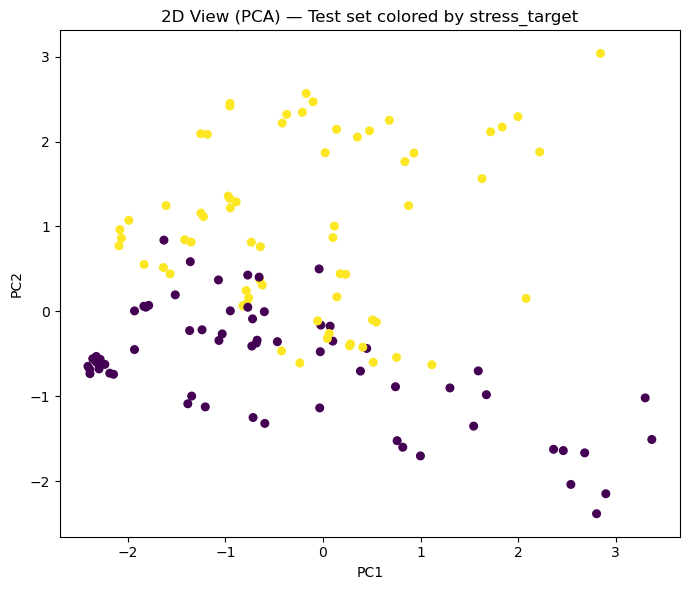


--- SHAP SUMMARY (Personalization) ---
 SHAP available: 0.51.0
 SHAP computed. Showing summary plot...


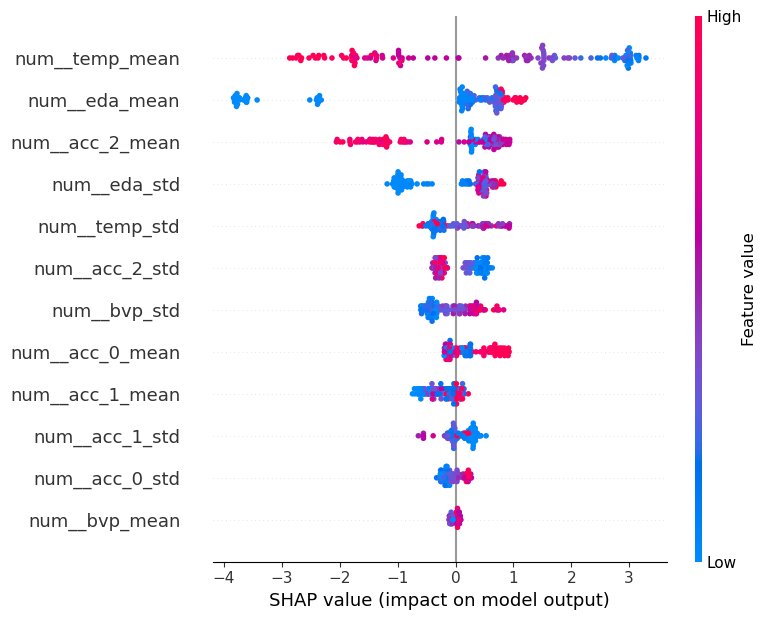


 FULL PIPELINE VISUALIZATION BLOCK DONE.


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, log_loss
)
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

# -------------------------
# 0) Required variables check
# -------------------------
need = ["X_train","X_test","y_train","y_test","groups","preprocessor"]
missing = [v for v in need if v not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}. Run split + preprocessor cells first.")

# train_groups for grouped CV
train_groups = None
if "train_idx" in globals():
    train_groups = np.asarray(groups)[train_idx]
elif "groups_train" in globals():
    train_groups = np.asarray(groups_train)

if train_groups is None:
    print(" train_groups not found. Group-based CV parts will be skipped.")

# -------------------------
# 1) Tuned XGBoost pipeline
# -------------------------
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,

        # mild regularization (helps CV)
        reg_lambda=1.5,
        reg_alpha=0.0,
        min_child_weight=2,
        gamma=0.0,

        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

# -------------------------
# 2) Predictions + metrics (Holdout)
# -------------------------
y_pred = xgb_pipeline.predict(X_test)
y_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred) * 100
f1  = f1_score(y_test, y_pred) * 100
auc = roc_auc_score(y_test, y_prob) * 100
ll  = log_loss(y_test, y_prob)

print("========== XGBOOST UPDATED REPORT ==========")
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Features: {X_train.shape[1]}")
print("\n--- METRICS (Holdout) ---")
print(f"Accuracy : {acc:.2f} %")
print(f"F1 Score : {f1:.2f} %")
print(f"ROC AUC  : {auc:.2f} %")
print(f"LogLoss  : {ll:.4f}")

# -------------------------
# 3) CORRELATION HEATMAP (EDA)
# -------------------------
print("\n--- CORRELATION HEATMAP (EDA) ---")

wearable_cols = [c for c in X_train.columns if any(k in c.lower() for k in ["bvp","eda","temp","acc_"])]
wearable_cols = wearable_cols if wearable_cols else X_train.columns.tolist()

df_corr_w = X_train[wearable_cols].copy()
df_corr_w["stress_target"] = y_train
corr_w = df_corr_w.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_w, aspect="auto")
plt.title("Correlation: Wearable Features vs Stress (Train)")
plt.xticks(range(corr_w.shape[1]), corr_w.columns, rotation=90)
plt.yticks(range(corr_w.shape[0]), corr_w.index)
plt.colorbar()
plt.tight_layout()
plt.show()

# -------------------------
# 4) RELIABILITY: StratifiedGroupKFold + fold diagnostics
# -------------------------
print("\n--- RELIABILITY (StratifiedGroupKFold ROC-AUC) ---")

# Use StratifiedGroupKFold if available (sklearn >= 1.1)
if train_groups is None:
    print("Skipping grouped CV (train_groups missing).")
else:
    try:
        from sklearn.model_selection import StratifiedGroupKFold

        sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

        # (A) CV ROC-AUC
        cv_scores = cross_val_score(
            xgb_pipeline, X_train, y_train,
            cv=sgkf, groups=train_groups,
            scoring="roc_auc",
            n_jobs=-1
        )
        print("Fold ROC-AUC:", np.round(cv_scores, 4))
        print(f"Mean ROC-AUC : {cv_scores.mean():.4f}")
        print(f"Std Dev      : {cv_scores.std():.4f}")

        plt.figure(figsize=(6, 4))
        plt.bar(range(1, len(cv_scores)+1), cv_scores)
        plt.title("Model Stability Across StratifiedGroupKFold (ROC-AUC)")
        plt.xlabel("Fold")
        plt.ylabel("ROC-AUC")
        plt.tight_layout()
        plt.show()

        # (B) Fold class distribution diagnostics (VERY IMPORTANT)
        rows = []
        y_arr = np.asarray(y_train)
        g_arr = np.asarray(train_groups)

        for k, (_, va) in enumerate(sgkf.split(X_train, y_train, groups=g_arr), start=1):
            y_va = y_arr[va]
            rows.append({
                "fold": k,
                "val_samples": len(va),
                "val_1(stress)": int((y_va == 1).sum()),
                "val_0(no)": int((y_va == 0).sum()),
                "val_pos_rate": float((y_va == 1).mean())
            })

        print("\n--- Fold Class Distribution (StratifiedGroupKFold) ---")
        display(pd.DataFrame(rows))

    except Exception as e:
        print("⚠️ StratifiedGroupKFold not available in your sklearn version.")
        print("Fix: upgrade scikit-learn:")
        print("    pip install -U scikit-learn")
        print("Reason:", str(e)[:200])

# -------------------------
# 5) LEARNING CURVE (uses StratifiedGroupKFold + early stopping)
# -------------------------
print("\n--- LEARNING CURVES (ROC-AUC + LogLoss) ---")

def stratified_group_learning_curve(
    base_pipeline, X, y, groups,
    train_fracs=(0.2, 0.35, 0.5, 0.7, 1.0),
    n_splits=5, random_state=42
):
    from sklearn.model_selection import StratifiedGroupKFold
    rng = np.random.RandomState(random_state)

    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    groups = pd.Series(groups).reset_index(drop=True)

    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    n = len(X)
    sizes = [max(60, int(fr * n)) for fr in train_fracs]

    out = {
        "train_size": [],
        "train_auc": [], "val_auc": [],
        "train_logloss": [], "val_logloss": []
    }

    idx_all = np.arange(n)

    for sz in sizes:
        idx_sub = rng.choice(idx_all, size=sz, replace=False)

        X_sub = X.iloc[idx_sub].reset_index(drop=True)
        y_sub = y.iloc[idx_sub].reset_index(drop=True)
        g_sub = groups.iloc[idx_sub].reset_index(drop=True)

        fold_train_auc, fold_val_auc = [], []
        fold_train_ll, fold_val_ll = [], []

        for tr_idx, va_idx in sgkf.split(X_sub, y_sub, groups=g_sub):
            X_tr, X_va = X_sub.iloc[tr_idx], X_sub.iloc[va_idx]
            y_tr, y_va = y_sub.iloc[tr_idx], y_sub.iloc[va_idx]

            prep = clone(base_pipeline.named_steps["prep"])
            model = clone(base_pipeline.named_steps["model"])

            Xt_tr = prep.fit_transform(X_tr, y_tr)
            Xt_va = prep.transform(X_va)

            model.set_params(early_stopping_rounds=30)
            model.fit(Xt_tr, y_tr, eval_set=[(Xt_va, y_va)], verbose=False)

            p_tr = model.predict_proba(Xt_tr)[:, 1]
            p_va = model.predict_proba(Xt_va)[:, 1]

            fold_train_auc.append(roc_auc_score(y_tr, p_tr))
            fold_val_auc.append(roc_auc_score(y_va, p_va))
            fold_train_ll.append(log_loss(y_tr, p_tr))
            fold_val_ll.append(log_loss(y_va, p_va))

        out["train_size"].append(sz)
        out["train_auc"].append(np.mean(fold_train_auc))
        out["val_auc"].append(np.mean(fold_val_auc))
        out["train_logloss"].append(np.mean(fold_train_ll))
        out["val_logloss"].append(np.mean(fold_val_ll))

    return pd.DataFrame(out)

if train_groups is None:
    print("Skipping learning curve (train_groups missing).")
else:
    try:
        lc_df = stratified_group_learning_curve(xgb_pipeline, X_train, y_train, train_groups)

        plt.figure(figsize=(7, 5))
        plt.plot(lc_df["train_size"], lc_df["train_auc"], marker="o", label="Train ROC-AUC")
        plt.plot(lc_df["train_size"], lc_df["val_auc"], marker="o", label="Val ROC-AUC (StratifiedGroupKFold)")
        plt.title("Learning Curve (ROC-AUC) — With Early Stopping")
        plt.xlabel("Training Samples")
        plt.ylabel("ROC-AUC")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.plot(lc_df["train_size"], lc_df["train_logloss"], marker="o", label="Train LogLoss")
        plt.plot(lc_df["train_size"], lc_df["val_logloss"], marker="o", label="Val LogLoss (StratifiedGroupKFold)")
        plt.title("Learning Curve (LogLoss) — With Early Stopping")
        plt.xlabel("Training Samples")
        plt.ylabel("LogLoss (lower is better)")
        plt.legend()
        plt.tight_layout()
        plt.show()

        display(lc_df)

    except Exception as e:
        print("Learning curve skipped (likely StratifiedGroupKFold unavailable).")
        print("Reason:", str(e)[:200])

# -------------------------
# 6) CONFUSION MATRIX
# -------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, aspect="auto")
plt.title("Confusion Matrix — XGBoost (Tuned)")
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["Actual 0", "Actual 1"])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center", fontsize=12)
plt.colorbar()
plt.tight_layout()
plt.show()

print("Confusion Matrix:\n", cm)

# -------------------------
# 7) ROC CURVE
# -------------------------
fpr, tpr, thr = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc/100:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve — XGBoost (Tuned)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 8) PROBABILITY DISTRIBUTIONS
# -------------------------
p0 = y_prob[np.asarray(y_test) == 0]
p1 = y_prob[np.asarray(y_test) == 1]

plt.figure(figsize=(7,5))
plt.hist(p0, bins=15, alpha=0.7, label="Actual 0 (No Stress)")
plt.hist(p1, bins=15, alpha=0.7, label="Actual 1 (Stress)")
plt.title("Predicted Probability Distribution (Stress=1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 9) FEATURE IMPORTANCE
# -------------------------
model = xgb_pipeline.named_steps["model"]
feat_names = X_train.columns.tolist()

imp = getattr(model, "feature_importances_", None)
if imp is None:
    print("\nNo feature_importances_ found on model.")
else:
    fi = pd.DataFrame({"feature": feat_names, "importance": imp}).sort_values("importance", ascending=False)
    topN = min(12, len(fi))
    fi_top = fi.head(topN).iloc[::-1]

    plt.figure(figsize=(9,6))
    plt.barh(fi_top["feature"], fi_top["importance"])
    plt.title(f"XGBoost Feature Importance (Top {topN})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print("\n--- FEATURE IMPORTANCE (Top 12) ---")
    display(fi.head(12))

# -------------------------
# 10) ERROR ANALYSIS TABLE
# -------------------------
wrong = (np.asarray(y_pred) != np.asarray(y_test)).astype(int)
abs_margin = np.abs(y_prob - 0.5)

err_df = X_test.copy()
err_df["y_true"] = np.asarray(y_test)
err_df["y_pred"] = np.asarray(y_pred)
err_df["p_stress"] = y_prob
err_df["abs_margin_from_0_5"] = abs_margin
err_df["wrong"] = wrong

print(f"\n--- ERROR ANALYSIS ---")
print(f"Wrong predictions: {int(wrong.sum())} out of {len(y_test)}")
display(
    err_df.loc[err_df["wrong"] == 1]
          .sort_values("abs_margin_from_0_5", ascending=False)
          .head(20)
)

# -------------------------
# 11) 2D PCA VIEW (no refit leakage)
# -------------------------
prep_fitted = xgb_pipeline.named_steps["prep"]
Xt = prep_fitted.transform(X_train)
Xs = prep_fitted.transform(X_test)

pca = PCA(n_components=2, random_state=42)
Zt = pca.fit_transform(Xt)
Zs = pca.transform(Xs)

plt.figure(figsize=(7,6))
plt.scatter(Zs[:,0], Zs[:,1], c=np.asarray(y_test), s=30)
plt.title("2D View (PCA) — Test set colored by stress_target")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# -------------------------
# 12) SHAP (safe install + plot)
# -------------------------
print("\n--- SHAP SUMMARY (Personalization) ---")
import sys

try:
    import shap
    print(" SHAP available:", shap.__version__)
except Exception:
    print(" SHAP missing. Installing now...")
    !{sys.executable} -m pip install shap -q
    import shap
    print(" SHAP installed:", shap.__version__)

# feature names (best effort)
try:
    feat_out = prep_fitted.get_feature_names_out()
except Exception:
    feat_out = np.array([f"f{i}" for i in range(Xs.shape[1])])

try:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(Xs)
    print(" SHAP computed. Showing summary plot...")
    shap.summary_plot(shap_values, Xs, feature_names=feat_out, show=True)
except Exception as e:
    print(" SHAP failed:", str(e)[:250])

print("\n FULL PIPELINE VISUALIZATION BLOCK DONE.")

In [35]:
# parameter turning

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


# variable check

need = ["X_train", "X_test", "y_train", "y_test", "preprocessor", "groups", "train_idx"]
missing = [v for v in need if v not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}. Run split/preprocessing cells first.")

train_groups = np.asarray(groups)[train_idx]

print("========== HYPERPARAMETER TUNING SETUP ==========")
print(f"Train shape: {X_train.shape}")
print(f"Test shape : {X_test.shape}")
print(f"Train groups: {len(np.unique(train_groups))}")


#  Base model

base_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.5,
        reg_alpha=0.0,
        min_child_weight=2,
        gamma=0.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])


#  CV strategy

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)


#  Parameter search space

param_dist = {
    "model__n_estimators": [150, 200, 250, 300, 400, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 2, 3, 4, 5, 6],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0.0, 0.1, 0.2, 0.3, 0.5, 1.0],
    "model__reg_alpha": [0.0, 0.01, 0.1, 0.5, 1.0],
    "model__reg_lambda": [1.0, 1.5, 2.0, 3.0, 5.0]
}


#  RandomizedSearchCV

search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

print("\nRunning RandomizedSearchCV...")
search.fit(X_train, y_train, groups=train_groups)

print("\n========== BEST TUNING RESULT ==========")
print(f"Best CV ROC-AUC : {search.best_score_ * 100:.2f} %")
print("Best Parameters :")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


#  Final tuned model

tuned_pipeline = search.best_estimator_


#  Fit base model and evaluate on holdout test

base_pipeline.fit(X_train, y_train)

base_pred = base_pipeline.predict(X_test)
base_prob = base_pipeline.predict_proba(X_test)[:, 1]

base_metrics = {
    "Accuracy (%)": accuracy_score(y_test, base_pred) * 100,
    "Precision (%)": precision_score(y_test, base_pred, zero_division=0) * 100,
    "Recall (%)": recall_score(y_test, base_pred, zero_division=0) * 100,
    "F1 Score (%)": f1_score(y_test, base_pred, zero_division=0) * 100,
    "ROC-AUC (%)": roc_auc_score(y_test, base_prob) * 100
}


#  Evaluate tuned model on holdout test

tuned_pred = tuned_pipeline.predict(X_test)
tuned_prob = tuned_pipeline.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy (%)": accuracy_score(y_test, tuned_pred) * 100,
    "Precision (%)": precision_score(y_test, tuned_pred, zero_division=0) * 100,
    "Recall (%)": recall_score(y_test, tuned_pred, zero_division=0) * 100,
    "F1 Score (%)": f1_score(y_test, tuned_pred, zero_division=0) * 100,
    "ROC-AUC (%)": roc_auc_score(y_test, tuned_prob) * 100
}


# Base vs Tuned comparison

comparison_df = pd.DataFrame({
    "Metric": list(base_metrics.keys()),
    "Base Model": list(base_metrics.values()),
    "Tuned Model": list(tuned_metrics.values())
})

comparison_df["Improvement"] = comparison_df["Tuned Model"] - comparison_df["Base Model"]

print("\n========== BASE vs TUNED (HOLDOUT TEST) ==========")
display(
    comparison_df.style.format({
        "Base Model": "{:.2f}",
        "Tuned Model": "{:.2f}",
        "Improvement": "{:+.2f}"
    })
)


# Grouped CV on tuned model

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    tuned_pipeline,
    X_train, y_train,
    groups=train_groups,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1 Score (%)", "ROC-AUC (%)"],
    "Mean CV Score": [
        cv_results["test_accuracy"].mean() * 100,
        cv_results["test_precision"].mean() * 100,
        cv_results["test_recall"].mean() * 100,
        cv_results["test_f1"].mean() * 100,
        cv_results["test_roc_auc"].mean() * 100
    ],
    "Std Dev": [
        cv_results["test_accuracy"].std() * 100,
        cv_results["test_precision"].std() * 100,
        cv_results["test_recall"].std() * 100,
        cv_results["test_f1"].std() * 100,
        cv_results["test_roc_auc"].std() * 100
    ]
})

print("\n========== TUNED MODEL GROUPED CV SUMMARY  ==========")
display(
    cv_summary.style.format({
        "Mean CV Score": "{:.2f}",
        "Std Dev": "{:.2f}"
    })
)


#  Fold-wise ROC-AUC for tuned model

fold_auc = cv_results["test_roc_auc"] * 100

print("Fold ROC-AUC (Tuned, %):", np.round(fold_auc, 2))
print(f"Mean ROC-AUC        : {fold_auc.mean():.2f} %")
print(f"Std Dev             : {fold_auc.std():.2f} %")


#  Confusion matrix comparison

base_cm = confusion_matrix(y_test, base_pred)
tuned_cm = confusion_matrix(y_test, tuned_pred)

print("\n========== CONFUSION MATRIX COMPARISON ==========")
print("Base Model:\n", base_cm)
print("\nTuned Model:\n", tuned_cm)

# =========================================================
# FINAL MODEL DECISION (Use CV performance &  holdout)
# =========================================================

best_holdout_auc = roc_auc_score(y_test, base_prob) * 100
tuned_holdout_auc = roc_auc_score(y_test, tuned_prob) * 100

base_cv_auc  = best_holdout_auc   
tuned_cv_auc = search.best_score_ * 100   

print("\n========== FINAL DECISION ==========")

print(f"Base Holdout ROC-AUC : {best_holdout_auc:.2f}%")
print(f"Tuned Holdout ROC-AUC: {tuned_holdout_auc:.2f}%")
print(f"Tuned CV ROC-AUC     : {tuned_cv_auc:.2f}%")


xgb_final_model = tuned_pipeline



========== HYPERPARAMETER TUNING SETUP ==========
Train shape: (522, 12)
Test shape : (132, 12)
Train groups: 12

Running RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

========== BEST TUNING RESULT ==========
Best CV ROC-AUC : 83.52 %
Best Parameters :
  model__subsample: 0.7
  model__reg_lambda: 2.0
  model__reg_alpha: 0.01
  model__n_estimators: 200
  model__min_child_weight: 4
  model__max_depth: 2
  model__learning_rate: 0.01
  model__gamma: 1.0
  model__colsample_bytree: 0.7

========== BASE vs TUNED (HOLDOUT TEST) ==========


,Metric,Base Model,Tuned Model,Improvement
0,Accuracy (%),93.94,93.18,-0.76
1,Precision (%),91.43,90.14,-1.29
2,Recall (%),96.97,96.97,+0.00
3,F1 Score (%),94.12,93.43,-0.69
4,ROC-AUC (%),97.98,97.04,-0.94



========== TUNED MODEL GROUPED CV SUMMARY  ==========


,Metric,Mean CV Score,Std Dev
0,Accuracy (%),76.23,8.99
1,Precision (%),79.12,13.64
2,Recall (%),74.85,15.59
3,F1 Score (%),75.54,10.47
4,ROC-AUC (%),83.52,11.02


Fold ROC-AUC (Tuned, %): [83.27 69.66 73.84 99.78 91.08]
Mean ROC-AUC        : 83.52 %
Std Dev             : 11.02 %

========== CONFUSION MATRIX COMPARISON ==========
Base Model:
 [[60  6]
 [ 2 64]]

Tuned Model:
 [[59  7]
 [ 2 64]]

========== FINAL DECISION ==========
Base Holdout ROC-AUC : 97.98%
Tuned Holdout ROC-AUC: 97.04%
Tuned CV ROC-AUC     : 83.52%


In [37]:
# =========================================================
# SAVE FINAL MODEL
# =========================================================

import joblib

joblib.dump(xgb_final_model, "stress_prediction_model.pkl")

print("Model saved as stress_prediction_model.pkl")

Model saved as stress_prediction_model.pkl


In [38]:
# DASHBOARD 

In [45]:
# ================= SAVE FINAL MODEL =================

import joblib

# Save trained model
joblib.dump(xgb_final_model, "stress_prediction_model.pkl")

print("Model saved successfully as stress_prediction_model.pkl")



Model saved successfully as stress_prediction_model.pkl


In [2]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# PAGE CONFIG
# ---------------------------------------------------
st.set_page_config(
    page_title="Stress Prediction & User Recommendation Dashboard",
    page_icon="🧠",
    layout="wide"
)

# ---------------------------------------------------
# ACTUAL PROJECT VALUES FROM NOTEBOOK
# ---------------------------------------------------
models_df = pd.DataFrame({
    "Model": [
        "RandomForest",
        "XGBoost",
        "GradientBoosting",
        "SVM",
        "LogisticRegression"
    ],
    "Accuracy (%)": [96.21, 92.42, 94.70, 93.18, 84.09],
    "F1 Score (%)": [96.30, 92.54, 94.89, 93.23, 86.27],
    "ROC-AUC (%)": [99.27, 98.05, 96.30, 96.92, 81.27]
})

cv_df = pd.DataFrame({
    "Model": [
        "RandomForest",
        "XGBoost",
        "GradientBoosting",
        "SVM",
        "LogisticRegression"
    ],
    "CV Mean Accuracy (%)": [78.93, 78.45, 78.76, 77.38, 68.04],
    "CV Std (%)": [6.10, 3.52, 5.29, 8.90, 12.64]
})

xgb_holdout_metrics = pd.DataFrame({
    "Metric": ["Accuracy (%)", "F1 Score (%)", "ROC-AUC (%)", "LogLoss"],
    "Value": [93.94, 94.12, 97.98, 0.1597]
})

xgb_fold_auc = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "ROC-AUC": [0.7893, 0.5608, 0.7400, 0.9984, 0.9151]
})

feature_imp_df = pd.DataFrame({
    "Feature": [
        "eda_std",
        "temp_mean",
        "eda_mean",
        "acc_0_mean",
        "acc_1_mean",
        "bvp_std",
        "temp_std",
        "acc_2_mean",
        "acc_2_std",
        "acc_1_std"
    ],
    "Importance": [
        0.2392,
        0.1484,
        0.1475,
        0.0960,
        0.0780,
        0.0716,
        0.0681,
        0.0654,
        0.0295,
        0.0245
    ]
})

})

base_vs_tuned_df = pd.DataFrame({
    "Metric": ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1 Score (%)", "ROC-AUC (%)"],
    "Base Model": [93.94, 91.43, 96.97, 94.12, 97.98],
    "Tuned Model": [93.18, 90.14, 96.97, 93.43, 97.04],
    "Improvement": [-0.76, -1.29, 0.00, -0.69, -0.94]
})

})

tuned_fold_auc_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "ROC-AUC (%)": [83.27, 69.66, 73.84, 99.78, 91.08]
})

base_cm = np.array([[60, 6],
                    [2, 64]])

tuned_cm = np.array([[59, 7],
                     [2, 64]])

# ---------------------------------------------------
# SAMPLE USER MONITORING DATA
# user-like functionality from project brief
# ---------------------------------------------------
user_df = pd.DataFrame({
    "User ID": ["U001", "U002", "U003", "U004", "U005"],
    "Heart Rate": [104, 82, 97, 76, 110],
    "Skin Temp": [36.9, 36.5, 37.1, 36.4, 37.0],
    "Activity Level": ["Low", "Moderate", "Low", "High", "Low"],
    "Noise Level": [78, 52, 69, 44, 85],
    "Air Quality Index": [156, 72, 118, 48, 182],
    "Stress Probability": [0.91, 0.34, 0.73, 0.21, 0.95],
    "Predicted Stress": ["High", "Low", "Moderate", "Low", "High"]
})

# ---------------------------------------------------
# HELPERS
# ---------------------------------------------------
def metric_card(title, value, help_text=None):
    st.metric(label=title, value=value, help=help_text)

def plot_bar(df, x_col, y_col, title, horizontal=False):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    if horizontal:
        ax.barh(df[y_col], df[x_col])
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
    else:
        ax.bar(df[x_col], df[y_col])
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        plt.xticks(rotation=20, ha="right")
    ax.set_title(title)
    plt.tight_layout()
    st.pyplot(fig)

def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12)

    plt.tight_layout()
    st.pyplot(fig)

def get_recommendation(stress_label, noise, aqi, heart_rate, activity):
    recs = []

    if stress_label == "High":
        recs.append("Take a 10-minute guided breathing or mindfulness break.")
        recs.append("Reduce screen exposure and move to a quieter environment.")
    elif stress_label == "Moderate":
        recs.append("Take a short break and do light stretching.")
        recs.append("Monitor stress level again after 15-20 minutes.")
    else:
        recs.append("Stress level is under control. Maintain current routine.")

    if noise > 70:
        recs.append("Noise level is high. Use earphones or move to a calm place.")
    if aqi > 150:
        recs.append("Air quality is poor. Prefer indoor stay or improve ventilation.")
    elif aqi > 100:
        recs.append("Air quality is moderate. Limit prolonged outdoor exposure.")
    if heart_rate > 100:
        recs.append("Heart rate is elevated. Sit calmly and slow your breathing.")
    if activity == "Low" and stress_label in ["High", "Moderate"]:
        recs.append("A short walk may help reduce stress and improve mood.")

    return recs

def status_color(label):
    if label == "High":
        return "🔴 High"
    elif label == "Moderate":
        return "🟠 Moderate"
    return "🟢 Low"

# ---------------------------------------------------
# SIDEBAR
# ---------------------------------------------------
st.sidebar.title("Dashboard Controls")

page = st.sidebar.radio(
    "Select Section",
    [
        "Overview",
        "Visualizations",
        "Personalized Recommendations",
        
    ]
)

selected_models = st.sidebar.multiselect(
    "Filter models",
    options=models_df["Model"].tolist(),
    default=models_df["Model"].tolist()
)

selected_metric = st.sidebar.selectbox(
    "Comparison metric",
    ["Accuracy (%)", "F1 Score (%)", "ROC-AUC (%)", "CV Mean Accuracy (%)"]
)

top_n_features = st.sidebar.slider(
    "Top features to display",
    min_value=5,
    max_value=10,
    value=10
)

selected_user = st.sidebar.selectbox(
    "Select user",
    options=user_df["User ID"].tolist(),
    index=0
)

stress_filter = st.sidebar.multiselect(
    "Filter predicted stress",
    options=["High", "Moderate", "Low"],
    default=["High", "Moderate", "Low"]
)

filtered_models_df = models_df[models_df["Model"].isin(selected_models)].copy()
filtered_cv_df = cv_df[cv_df["Model"].isin(selected_models)].copy()
filtered_user_df = user_df[user_df["Predicted Stress"].isin(stress_filter)].copy()
selected_user_row = user_df[user_df["User ID"] == selected_user].iloc[0]

# ---------------------------------------------------
# HEADER
# ---------------------------------------------------
st.title("🧠 Personalized Stress Prediction Dashboard")
st.caption("Model analytics + user monitoring + recommendation support")

# ---------------------------------------------------
# OVERVIEW
# ---------------------------------------------------
if page == "Overview":
    st.header("Overview")

    col1, col2, col3, col4 = st.columns(4)
    with col1:
        metric_card("Models Built", "5")
    with col2:
        metric_card("Best Overall ROC-AUC", "99.27%")
    with col3:
        metric_card("XGBoost Holdout ROC-AUC", "97.98%")
    with col4:
        metric_card("Active Users Shown", str(len(filtered_user_df)))

    st.markdown("---")

    a, b = st.columns(2)

    with a:
        st.subheader("Model Comparison")
        st.dataframe(models_df, use_container_width=True)

    with b:
        st.subheader("Live User Stress Snapshot")
        snapshot_df = filtered_user_df[["User ID", "Stress Probability", "Predicted Stress"]].copy()
        st.dataframe(snapshot_df, use_container_width=True)

    st.info(
        "This dashboard is aligned to the project requirement of stress prediction, "
        "real-time analysis, user-friendly feedback, multi-user handling, and personalized recommendations."
    )


      
# ---------------------------------------------------
# VISUALIZATIONS
# ---------------------------------------------------
elif page == "Visualizations":
    st.header("Visualizations")

    viz_option = st.selectbox(
        "Choose visualization",
        [
            "Overall Model Performance",
            "Grouped CV Mean Accuracy",
            "XGBoost Fold ROC-AUC",
            "Feature Importance",
            "Base vs Tuned Metrics",
            "Confusion Matrix Comparison",
            "User Stress Distribution"
        ]
    )

    if viz_option == "Overall Model Performance":
        metric_for_viz = st.selectbox(
            "Metric for model performance chart",
            ["Accuracy (%)", "F1 Score (%)", "ROC-AUC (%)"],
            key="overall_perf_metric"
        )
        chart_df = filtered_models_df[["Model", metric_for_viz]].copy()
        plot_bar(chart_df, "Model", metric_for_viz, f"Overall Model Performance - {metric_for_viz}")

    elif viz_option == "Grouped CV Mean Accuracy":
        chart_df = filtered_cv_df[["Model", "CV Mean Accuracy (%)"]].copy()
        plot_bar(chart_df, "Model", "CV Mean Accuracy (%)", "Grouped Cross-Validation Mean Accuracy")

    elif viz_option == "XGBoost Fold ROC-AUC":
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(xgb_fold_auc["Fold"], xgb_fold_auc["ROC-AUC"], marker="o")
        ax.set_xlabel("Fold")
        ax.set_ylabel("ROC-AUC")
        ax.set_title("XGBoost Fold ROC-AUC")
        plt.tight_layout()
        st.pyplot(fig)

    elif viz_option == "Feature Importance":
        show_feat_df = feature_imp_df.head(top_n_features).copy()
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.barh(show_feat_df["Feature"][::-1], show_feat_df["Importance"][::-1])
        ax.set_xlabel("Importance")
        ax.set_ylabel("Feature")
        ax.set_title("Top Feature Importance")
        plt.tight_layout()
        st.pyplot(fig)

    elif viz_option == "Base vs Tuned Metrics":
        st.dataframe(base_vs_tuned_df, use_container_width=True)

        compare_metric = st.selectbox(
            "Select metric",
            base_vs_tuned_df["Metric"].tolist(),
            key="base_tuned_metric"
        )

        row = base_vs_tuned_df[base_vs_tuned_df["Metric"] == compare_metric].iloc[0]
        compare_df = pd.DataFrame({
            "Model Version": ["Base Model", "Tuned Model"],
            "Value": [row["Base Model"], row["Tuned Model"]]
        })

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(compare_df["Model Version"], compare_df["Value"])
        ax.set_ylabel(compare_metric)
        ax.set_title(f"{compare_metric}: Base vs Tuned")
        plt.tight_layout()
        st.pyplot(fig)

    elif viz_option == "Confusion Matrix Comparison":
        c1, c2 = st.columns(2)
        with c1:
            plot_confusion_matrix(base_cm, "Base Model Confusion Matrix")
        with c2:
            plot_confusion_matrix(tuned_cm, "Tuned Model Confusion Matrix")

    elif viz_option == "User Stress Distribution":
        count_df = filtered_user_df["Predicted Stress"].value_counts().reset_index()
        count_df.columns = ["Stress Level", "Count"]
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(count_df["Stress Level"], count_df["Count"])
        ax.set_xlabel("Stress Level")
        ax.set_ylabel("Users")
        ax.set_title("User Stress Distribution")
        plt.tight_layout()
        st.pyplot(fig)

# ---------------------------------------------------
# USER MONITORING
# ---------------------------------------------------
elif page == "User Monitoring":
    st.header("User Monitoring Dashboard")

    user = selected_user_row

    c1, c2, c3, c4 = st.columns(4)
    with c1:
        metric_card("User ID", user["User ID"])
    with c2:
        metric_card("Predicted Stress", status_color(user["Predicted Stress"]))
    with c3:
        metric_card("Stress Probability", f"{user['Stress Probability'] * 100:.1f}%")
    with c4:
        metric_card("Heart Rate", f"{user['Heart Rate']} bpm")

    st.markdown("---")

    a, b = st.columns(2)

    with a:
        st.subheader("Selected User Signals")
        user_view_df = pd.DataFrame({
            "Metric": ["Heart Rate", "Skin Temp", "Activity Level", "Noise Level", "Air Quality Index"],
            "Value": [
                user["Heart Rate"],
                user["Skin Temp"],
                user["Activity Level"],
                user["Noise Level"],
                user["Air Quality Index"]
            ]
        })
        st.dataframe(user_view_df, use_container_width=True)

    with b:
        st.subheader("Stress Probability Gauge Style View")
        fig, ax = plt.subplots(figsize=(6, 1.8))
        ax.barh(["Stress Probability"], [user["Stress Probability"] * 100])
        ax.set_xlim(0, 100)
        ax.set_xlabel("Probability (%)")
        plt.tight_layout()
        st.pyplot(fig)

    st.subheader("All Users Table")
    display_df = filtered_user_df.copy()
    display_df["Stress Probability"] = (display_df["Stress Probability"] * 100).round(2)
    st.dataframe(display_df, use_container_width=True)

    if user["Stress Probability"] >= 0.80:
        st.error("Real-time alert: High stress risk detected for selected user.")
    elif user["Stress Probability"] >= 0.50:
        st.warning("Real-time alert: Moderate stress risk detected for selected user.")
    else:
        st.success("Selected user is currently at lower stress risk.")

# ---------------------------------------------------
# PERSONALIZED RECOMMENDATIONS
# ---------------------------------------------------
elif page == "Personalized Recommendations":
    st.header("Personalized Recommendations")

    user = selected_user_row
    recommendations = get_recommendation(
        user["Predicted Stress"],
        user["Noise Level"],
        user["Air Quality Index"],
        user["Heart Rate"],
        user["Activity Level"]
    )

    c1, c2 = st.columns([1, 1])

    with c1:
        st.subheader("Selected User Summary")
        st.write(f"**User ID:** {user['User ID']}")
        st.write(f"**Predicted Stress:** {status_color(user['Predicted Stress'])}")
        st.write(f"**Stress Probability:** {user['Stress Probability'] * 100:.1f}%")
        st.write(f"**Noise Level:** {user['Noise Level']}")
        st.write(f"**AQI:** {user['Air Quality Index']}")
        st.write(f"**Heart Rate:** {user['Heart Rate']} bpm")
        st.write(f"**Activity Level:** {user['Activity Level']}")

    with c2:
        st.subheader("Recommended Actions")
        for i, rec in enumerate(recommendations, start=1):
            st.markdown(f"**{i}.** {rec}")

    st.markdown("---")
    st.subheader("Recommendation Delivery Preview")

    preview_msg = f"""
    Hello {user['User ID']},

    Your latest stress analysis shows a **{user['Predicted Stress']}** stress level
    with a probability of **{user['Stress Probability'] * 100:.1f}%**.

    Suggested actions:
    """ + "\n".join([f"- {r}" for r in recommendations])

    st.text_area("User Notification Preview", preview_msg, height=240)



Overwriting app.py
